### **WP3.7 Subgroup Analysis**

##### **Notebook Outline**

- **setup and input checks**: load saved model predictions, test identifiers, and engineered subgroup fields.
- **subgroup dictionary**: define demographic, diagnosis, prior-use, discharge-pathway, medical-complexity, care-process, and outcome-window groups.
- **global subgroup performance**: evaluate the selected saved model across all subgroup definitions.
- **pairwise subgroup contrasts**: compare subgroup versus complement to highlight larger performance gaps.
- **error enrichment**: identify groups over-represented in false positives and false negatives.
- **intersection subgroups**: test combined groups such as older medical complexity and home discharge with psychiatric risk.
- **reliability and confidence intervals**: flag small subgroups and estimate uncertainty around subgroup performance.
- **demographic fairness summary**: collect demographic subgroup rows into one review table.
- **error and outcome-window summaries**: highlight false-positive/false-negative enrichment and wider-window readmission patterns.
- **report-ready summaries**: create best/worst rankings, older-patient focus tables, and short interpretation labels.
- **age-group subgroup training**: compare saved global predictions with age-group-only LightGBM models using fixed and subgroup-selected thresholds.
- **diagnosis-group transfer learning**: compare saved global predictions with diagnosis-only and warm-start LightGBM models using fixed and subgroup-selected thresholds.
- **diagnosis cross-testing matrix**: evaluate each diagnosis-trained model across each diagnosis-defined test group and save heatmaps.
- **export tables**: save CSV tables and one workbook for easier review.


In [230]:
import sys
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
from scipy import sparse
from scipy.stats import chi2_contingency
from sklearn.metrics import (accuracy_score, average_precision_score, balanced_accuracy_score,
    brier_score_loss, confusion_matrix, f1_score, precision_score, recall_score, roc_auc_score)
from sklearn.model_selection import train_test_split

warnings.filterwarnings("ignore")
print("python executable:", sys.executable)

python executable: /Users/ahthini/Desktop/DissProject/my_env/bin/python


##### **Setup Paths**

This section keeps the notebook tied to the project folder and creates a separate output folder so subgroup analyses do not overwrite the main model-comparison outputs.

In [231]:
#detect the project root on remote lab or local mac before running
project_candidates = [Path("/scratch/DissProject"), Path("/Users/ahthini/Desktop/DissProject"), Path.cwd().parent]
project_path = next((path for path in project_candidates if (path / "outputs").exists()), project_candidates[0])
output_path = project_path / "outputs"
wp3_1_output_path = output_path / "WP3_1"
wp3_4_output_path = output_path / "WP3_4"
wp3_5_output_path = output_path / "WP3_5"
wp3_6_output_path = output_path / "WP3_6"
wp3_7_output_path = output_path / "WP3_7"
wp3_7_csv_output_path = wp3_7_output_path / "csv_tables"

#make output folders before any exports are attempted
wp3_7_csv_output_path.mkdir(parents=True, exist_ok=True)
print("WP3.7 output folder:", wp3_7_output_path)

WP3.7 output folder: /Users/ahthini/Desktop/DissProject/outputs/WP3_7


##### **Load Inputs**

This section loads the engineered admission-level dataset, the held-out test identifiers, and the strongest available saved prediction table. The ensemble prediction table is preferred because it reflects the final model-comparison stage, but the notebook falls back to targeted LightGBM if needed.

In [232]:
#load engineered features and the fixed held-out test identifiers
engineered_dataset_path = output_path / "t2_3_engineered_dataset.csv"
test_ids_path = wp3_1_output_path / "t3_1_test_ids.csv"
if not engineered_dataset_path.exists():
    raise FileNotFoundError(f"missing engineered dataset: {engineered_dataset_path}")
if not test_ids_path.exists():
    raise FileNotFoundError(f"missing test id file: {test_ids_path}")

engineered_df = pd.read_csv(engineered_dataset_path, low_memory=False)
test_ids = pd.read_csv(test_ids_path)
print("engineered dataset shape:", engineered_df.shape)
print("test ids shape:", test_ids.shape)

engineered dataset shape: (238491, 1442)
test ids shape: (47171, 13)


In [233]:
#choose the best available saved prediction source for subgroup evaluation
prediction_candidates = [
    (wp3_6_output_path / "csv_tables" / "t3_6_probability_ensemble_predictions.csv", "WP3.6", "ensemble"),
    (wp3_4_output_path / "lightgbm_targeted" / "t3_4_lightgbm_targeted_test_predictions.csv", "WP3.4", "targeted_lightgbm"),
    (wp3_6_output_path / "reduced_feature_sensitivity" / "lightgbm_targeted" / "shap_guided_reduced_feature_set" / "t3_reduced_lightgbm_targeted_shap_guided_reduced_feature_set_test_predictions.csv", "WP3.6", "targeted_lightgbm_shap_guided")]

prediction_df = None
prediction_source = None
for prediction_path, source_notebook, source_label in prediction_candidates:
    if prediction_path.exists():
        candidate_df = pd.read_csv(prediction_path)
        if "predicted_probability" in candidate_df.columns and "readmitted_30d" in candidate_df.columns:
            #if an ensemble file contains multiple model rows, keep the highest-pr-auc ensemble if model labels are repeated
            if candidate_df.duplicated(["subject_id", "hadm_id"]).any() and "model_family" in candidate_df.columns:
                if (wp3_6_output_path / "csv_tables" / "t3_6_probability_ensemble_performance.csv").exists():
                    ensemble_perf = pd.read_csv(wp3_6_output_path / "csv_tables" / "t3_6_probability_ensemble_performance.csv")
                    best_family = ensemble_perf.sort_values("pr_auc_average_precision", ascending=False).iloc[0]["model_family"]
                    candidate_df = candidate_df.loc[candidate_df["model_family"].eq(best_family)].copy()
            prediction_df = candidate_df.reset_index(drop=True)
            prediction_source = {"path": prediction_path, "source_notebook": source_notebook, "source_label": source_label}
            break

if prediction_df is None:
    raise FileNotFoundError("no usable saved prediction file was found")

print("prediction source:", prediction_source)
print("prediction shape:", prediction_df.shape)
print(prediction_df.head())

prediction source: {'path': PosixPath('/Users/ahthini/Desktop/DissProject/outputs/WP3_6/csv_tables/t3_6_probability_ensemble_predictions.csv'), 'source_notebook': 'WP3.6', 'source_label': 'ensemble'}
prediction shape: (47171, 12)
   subject_id   hadm_id  readmitted_30d  predicted_probability  \
0    10000117  22927623               0               0.085951   
1    10000117  27988844               0               0.085418   
2    10002221  21008195               0               0.112907   
3    10002221  20195471               0               0.110964   
4    10002221  21729093               1               0.270876   

                         model_family                       model_group  \
0  Ensemble - LightGBM-heavy blend 50  ensemble_lightgbm-heavy_blend_50   
1  Ensemble - LightGBM-heavy blend 50  ensemble_lightgbm-heavy_blend_50   
2  Ensemble - LightGBM-heavy blend 50  ensemble_lightgbm-heavy_blend_50   
3  Ensemble - LightGBM-heavy blend 50  ensemble_lightgbm-heavy_blend_50  

In [234]:
#join subgroup fields onto the held-out predictions by admission id
id_cols = [col for col in ["subject_id", "hadm_id"] if col in prediction_df.columns and col in engineered_df.columns]
if len(id_cols) < 2:
    raise ValueError("subject_id and hadm_id are needed to join subgroup features")

subgroup_source_cols = [col for col in engineered_df.columns if col not in ["readmitted_30d"]]
subgroup_source_df = engineered_df[subgroup_source_cols].drop_duplicates(id_cols)
window_columns = [col for col in ["days_to_next", "readmitted_14d_psych", "readmitted_60d_psych", "readmitted_90d_psych", "readmitted_365d_psych"] if col in test_ids.columns]
if window_columns:
    window_df = test_ids[id_cols + window_columns].drop_duplicates(id_cols)
    prediction_df = prediction_df.drop(columns=[col for col in window_columns if col in prediction_df.columns], errors="ignore")
    prediction_df = prediction_df.merge(window_df, on=id_cols, how="left")
analysis_df = prediction_df.merge(subgroup_source_df, on=id_cols, how="left", suffixes=("", "_feature"), indicator="subgroup_join_status")
subgroup_join_audit_df = analysis_df["subgroup_join_status"].value_counts(dropna=False).rename_axis("join_status").reset_index(name="admissions")
subgroup_join_audit_df["admission_share"] = subgroup_join_audit_df["admissions"] / len(analysis_df)
subgroup_join_audit_df.to_csv(wp3_7_csv_output_path / "t3_7_subgroup_join_audit.csv", index=False)
analysis_df = analysis_df.drop(columns=["subgroup_join_status"])
analysis_df["readmitted_30d"] = analysis_df["readmitted_30d"].astype(int)
analysis_df["predicted_probability"] = pd.to_numeric(analysis_df["predicted_probability"], errors="coerce")
if "threshold" in analysis_df.columns and analysis_df["threshold"].notna().any():
    primary_threshold = float(pd.to_numeric(analysis_df["threshold"], errors="coerce").dropna().iloc[0])
else:
    primary_threshold = 0.30
analysis_df["predicted_class"] = (analysis_df["predicted_probability"] >= primary_threshold).astype(int)
analysis_df["classification_group"] = np.select([
        (analysis_df["readmitted_30d"].eq(1)) & (analysis_df["predicted_class"].eq(1)),
        (analysis_df["readmitted_30d"].eq(0)) & (analysis_df["predicted_class"].eq(1)),
        (analysis_df["readmitted_30d"].eq(1)) & (analysis_df["predicted_class"].eq(0)),
        (analysis_df["readmitted_30d"].eq(0)) & (analysis_df["predicted_class"].eq(0))],
    ["true_positive", "false_positive", "false_negative", "true_negative"], default="unclassified")

subgroup_metric_df = analysis_df[["readmitted_30d", "predicted_probability", "predicted_class", "classification_group"]].copy()

print("subgroup join audit:")
display(subgroup_join_audit_df)
print("analysis shape:", analysis_df.shape)
print("metric frame shape:", subgroup_metric_df.shape)
print("primary threshold:", primary_threshold)
print("classification groups:")
print(analysis_df["classification_group"].value_counts())

subgroup join audit:


,join_status,admissions,admission_share
0,both,47171,1.0
1,left_only,0,0.0
2,right_only,0,0.0


analysis shape: (47171, 1456)
metric frame shape: (47171, 4)
primary threshold: 0.38
classification groups:
classification_group
true_negative     33354
true_positive      4988
false_positive     4498
false_negative     4331
Name: count, dtype: int64


##### **Helper Functions**

These helpers keep subgroup scoring consistent across every group. Metrics are only calculated when both outcome classes are present, which avoids subgroup failures when a small group has no readmitted cases.

In [235]:
#calculate auc-style metrics only when both outcome classes are present
def safe_auc(metric_function, y_true, y_probability):
    if pd.Series(y_true).nunique() < 2:
        return np.nan
    return metric_function(y_true, y_probability)

#calculate discrimination, calibration, and threshold metrics for one subgroup
def evaluate_subgroup(frame, subgroup_family, subgroup_name, subgroup_value, threshold=primary_threshold):
    y_true = frame["readmitted_30d"].astype(int).to_numpy()
    y_probability = frame["predicted_probability"].astype(float).to_numpy()
    y_predicted = (y_probability >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_predicted, labels=[0, 1]).ravel()
    return {"subgroup_family": subgroup_family,
        "subgroup_name": subgroup_name,
        "subgroup_value": subgroup_value,
        "admissions": len(frame),
        "readmissions": int(y_true.sum()),
        "readmission_rate": float(np.mean(y_true)) if len(y_true) else np.nan,
        "mean_predicted_probability": float(np.mean(y_probability)) if len(y_probability) else np.nan,
        "threshold": threshold,
        "roc_auc": safe_auc(roc_auc_score, y_true, y_probability),
        "pr_auc_average_precision": safe_auc(average_precision_score, y_true, y_probability),
        "brier_score": brier_score_loss(y_true, y_probability) if len(y_true) else np.nan,
        "precision": precision_score(y_true, y_predicted, zero_division=0),
        "recall_sensitivity": recall_score(y_true, y_predicted, zero_division=0),
        "specificity": tn / (tn + fp) if (tn + fp) else np.nan,
        "f1_score": f1_score(y_true, y_predicted, zero_division=0),
        "balanced_accuracy": balanced_accuracy_score(y_true, y_predicted) if pd.Series(y_true).nunique() == 2 else np.nan,
        "true_negatives": int(tn), "false_positives": int(fp), "false_negatives": int(fn), "true_positives": int(tp)}


#select a threshold on training predictions without using held-out subgroup outcomes
def select_training_f1_threshold(y_true_values, y_probability_values, minimum_predicted_positive=25, minimum_true_positive=25):
    y_true_values = np.asarray(y_true_values).astype(int)
    y_probability_values = np.asarray(y_probability_values).astype(float)
    threshold_rows = []
    if len(y_true_values) == 0 or pd.Series(y_true_values).nunique() < 2:
        return {"selected_threshold": primary_threshold,
            "threshold_selection_metric": "training_f1",
            "threshold_selection_note": "Default final threshold retained because the training subgroup had insufficient outcome variation.",
            "selected_threshold_training_f1": np.nan,
            "selected_threshold_training_precision": np.nan,
            "selected_threshold_training_recall": np.nan}
    for threshold in np.round(np.arange(0.01, 1.00, 0.01), 2):
        y_predicted = (y_probability_values >= threshold).astype(int)
        true_positives = int(((y_predicted == 1) & (y_true_values == 1)).sum())
        predicted_positive_count = int(y_predicted.sum())
        threshold_rows.append({"threshold": float(threshold),
            "precision": precision_score(y_true_values, y_predicted, zero_division=0),
            "recall_sensitivity": recall_score(y_true_values, y_predicted, zero_division=0),
            "f1_score": f1_score(y_true_values, y_predicted, zero_division=0),
            "predicted_positive_count": predicted_positive_count,
            "true_positives": true_positives})
    threshold_df = pd.DataFrame(threshold_rows)
    usable_thresholds = threshold_df.loc[(threshold_df["predicted_positive_count"] >= minimum_predicted_positive) &
        (threshold_df["true_positives"] >= minimum_true_positive)].copy()
    if usable_thresholds.empty:
        usable_thresholds = threshold_df.copy()
        selection_note = "Fallback threshold selected by training F1 because no threshold met the minimum positive-prediction criteria."
    else:
        selection_note = "Threshold selected by maximising training-subgroup F1 among usable thresholds."
    selected_row = usable_thresholds.sort_values(["f1_score", "precision", "recall_sensitivity"], ascending=False).iloc[0]
    return {"selected_threshold": float(selected_row["threshold"]),
        "threshold_selection_metric": "training_f1",
        "threshold_selection_note": selection_note,
        "selected_threshold_training_f1": float(selected_row["f1_score"]),
        "selected_threshold_training_precision": float(selected_row["precision"]),
        "selected_threshold_training_recall": float(selected_row["recall_sensitivity"])}


#select recall-oriented thresholds on training predictions without using held-out subgroup outcomes
def select_training_recall_thresholds(y_true_values, y_probability_values, recall_targets=(0.60, 0.70, 0.80),
        minimum_predicted_positive=25, minimum_true_positive=25):
    y_true_values = np.asarray(y_true_values).astype(int)
    y_probability_values = np.asarray(y_probability_values).astype(float)
    if len(y_true_values) == 0 or pd.Series(y_true_values).nunique() < 2:
        return [{"selected_threshold": primary_threshold,
            "threshold_selection_metric": f"training_recall_target_{int(target * 100)}",
            "threshold_selection_note": "Default final threshold retained because the training subgroup had insufficient outcome variation.",
            "target_recall": float(target),
            "selected_threshold_training_f1": np.nan,
            "selected_threshold_training_precision": np.nan,
            "selected_threshold_training_recall": np.nan,
            "selected_threshold_training_specificity": np.nan,
            "selected_threshold_training_predicted_positive_rate": np.nan}
            for target in recall_targets]

    threshold_rows = []
    for threshold in np.round(np.arange(0.01, 1.00, 0.01), 2):
        y_predicted = (y_probability_values >= threshold).astype(int)
        tn, fp, fn, tp = confusion_matrix(y_true_values, y_predicted, labels=[0, 1]).ravel()
        threshold_rows.append({"threshold": float(threshold),
            "precision": precision_score(y_true_values, y_predicted, zero_division=0),
            "recall_sensitivity": recall_score(y_true_values, y_predicted, zero_division=0),
            "specificity": tn / (tn + fp) if (tn + fp) else np.nan,
            "f1_score": f1_score(y_true_values, y_predicted, zero_division=0),
            "predicted_positive_count": int(y_predicted.sum()),
            "predicted_positive_rate": float(y_predicted.mean()),
            "true_positives": int(tp)})
    threshold_df = pd.DataFrame(threshold_rows)
    usable_thresholds = threshold_df.loc[(threshold_df["predicted_positive_count"] >= minimum_predicted_positive) &
        (threshold_df["true_positives"] >= minimum_true_positive)].copy()
    if usable_thresholds.empty:
        usable_thresholds = threshold_df.copy()

    selected_thresholds = []
    for target in recall_targets:
        target_candidates = usable_thresholds.loc[usable_thresholds["recall_sensitivity"] >= target].copy()
        if target_candidates.empty:
            selected_row = usable_thresholds.sort_values(["recall_sensitivity", "precision", "f1_score"], ascending=False).iloc[0]
            selection_note = f"Fallback: no usable training threshold met recall target {target:.2f}; highest available recall was selected."
        else:
            selected_row = target_candidates.sort_values(["precision", "f1_score", "specificity", "threshold"],
                ascending=[False, False, False, False]).iloc[0]
            selection_note = f"Threshold selected on training subgroup predictions to meet recall target {target:.2f} with highest available precision."
        selected_thresholds.append({"selected_threshold": float(selected_row["threshold"]),
            "threshold_selection_metric": f"training_recall_target_{int(target * 100)}",
            "threshold_selection_note": selection_note,
            "target_recall": float(target),
            "selected_threshold_training_f1": float(selected_row["f1_score"]),
            "selected_threshold_training_precision": float(selected_row["precision"]),
            "selected_threshold_training_recall": float(selected_row["recall_sensitivity"]),
            "selected_threshold_training_specificity": float(selected_row["specificity"]),
            "selected_threshold_training_predicted_positive_rate": float(selected_row["predicted_positive_rate"])})
    return selected_thresholds

#return a numeric column if present, otherwise return zeros for optional fields
def numeric_or_zero(frame, column):
    if column in frame.columns:
        return pd.to_numeric(frame[column], errors="coerce").fillna(0)
    return pd.Series(0, index=frame.index)

#return a string column if present, otherwise return missing labels for optional fields
def string_or_missing(frame, column):
    if column in frame.columns:
        return frame[column].astype(str).fillna("missing")
    return pd.Series("missing", index=frame.index)

#add a subgroup definition if it has enough admissions and enough outcome variation
def add_subgroup_definition(definitions, family, name, mask, minimum_size=100):
    mask = pd.Series(mask, index=analysis_df.index).fillna(False).astype(bool)
    if int(mask.sum()) >= minimum_size:
        definitions.append({"subgroup_family": family, "subgroup_name": name, "mask": mask})

##### **Subgroup Definitions**

The groups are intentionally broad enough to be clinically interpretable but specific enough to show where performance changes. The notebook builds only groups that are actually present in the local dataset.

In [236]:
#build binary subgroup definitions across demographic, diagnostic, pathway, and acuity domains
subgroup_definitions = []

#demographic groups
if "gender" in analysis_df.columns:
    for gender_value in sorted(analysis_df["gender"].dropna().astype(str).unique()):
        add_subgroup_definition(subgroup_definitions, "demographics", f"gender_{gender_value}", string_or_missing(analysis_df, "gender").eq(gender_value))
if "anchor_age" in analysis_df.columns:
    age = numeric_or_zero(analysis_df, "anchor_age")
    add_subgroup_definition(subgroup_definitions, "demographics", "age_under_40", age.lt(40))
    add_subgroup_definition(subgroup_definitions, "demographics", "age_40_to_64", age.between(40, 64, inclusive="both"))
    add_subgroup_definition(subgroup_definitions, "demographics", "age_65plus", age.ge(65))
    add_subgroup_definition(subgroup_definitions, "demographics", "age_70plus", age.ge(70))
    add_subgroup_definition(subgroup_definitions, "demographics", "age_80plus", age.ge(80))
for column in ["insurance_grouped", "race", "marital_status", "language"]:
    if column in analysis_df.columns:
        common_values = analysis_df[column].astype(str).value_counts().head(8).index.tolist()
        for value in common_values:
            add_subgroup_definition(subgroup_definitions, "demographics", f"{column}_{value}", string_or_missing(analysis_df, column).eq(value), minimum_size=250)

#diagnosis and psychiatric-risk groups
for column in ["has_self_harm_or_suicidal_ideation", "has_psychotic_disorder", "has_bipolar_disorder", "has_depression",
        "has_substance_use", "has_personality_disorder", "has_anxiety_ptsd", "has_cognitive_delirium",
        "has_severe_mental_illness", "psychosis_and_substance_use_flag", "depression_and_substance_use_flag",
        "self_harm_and_substance_use_flag", "new_self_harm_this_admission_flag", "new_psychosis_this_admission_flag"]:
    add_subgroup_definition(subgroup_definitions, "diagnosis", column, numeric_or_zero(analysis_df, column).gt(0))

#prior utilisation groups
for column in ["previous_total_admissions", "previous_psych_admissions_365d", "previous_psych_admissions_90d",
        "previous_nonpsych_admissions_365d", "previous_ed_visits_365d", "previous_icu_admissions"]:
    values = numeric_or_zero(analysis_df, column)
    if values.gt(0).any():
        add_subgroup_definition(subgroup_definitions, "prior_utilisation", f"{column}_any", values.gt(0))
        add_subgroup_definition(subgroup_definitions, "prior_utilisation", f"{column}_high", values.ge(values.quantile(0.90)))
add_subgroup_definition(subgroup_definitions, "prior_utilisation", "low_psych_history_but_prior_admissions", numeric_or_zero(analysis_df, "previous_psych_admissions_365d").eq(0) & numeric_or_zero(analysis_df, "previous_total_admissions").gt(0))

#discharge and aftercare pathway groups
for column in ["discharged_home_flag", "discharged_to_facility_flag", "discharged_to_psych_facility_flag", "discharged_against_advice",
        "protective_aftercare_present_flag", "low_aftercare_quality_flag", "home_discharge_without_followup_order_flag",
        "home_discharge_without_discharge_planning_order_flag", "had_psych_followup_order", "had_substance_use_followup_order"]:
    add_subgroup_definition(subgroup_definitions, "discharge_pathway", column, numeric_or_zero(analysis_df, column).gt(0))
add_subgroup_definition(subgroup_definitions, "discharge_pathway", "home_discharge_with_psych_risk", numeric_or_zero(analysis_df, "discharged_home_flag").gt(0) & (
    numeric_or_zero(analysis_df, "has_self_harm_or_suicidal_ideation").gt(0) | numeric_or_zero(analysis_df, "has_psychotic_disorder").gt(0) | numeric_or_zero(analysis_df, "has_severe_mental_illness").gt(0)))

#medical complexity and icu groups
charlson = numeric_or_zero(analysis_df, "charlson_comorbidity_index_simplified")
add_subgroup_definition(subgroup_definitions, "medical_complexity", "charlson_3plus", charlson.ge(3))
add_subgroup_definition(subgroup_definitions, "medical_complexity", "charlson_5plus", charlson.ge(5))
for column in ["had_icu_stay", "age_65plus_x_charlson", "vital_instability_near_discharge_score", "abnormal_vital_last_24h_before_discharge_flag",
        "critical_lab_result_last_24h_before_discharge_flag", "medical_complexity_no_aftercare_flag", "renal_or_cardiopulmonary_complexity_flag"]:
    add_subgroup_definition(subgroup_definitions, "medical_complexity", column, numeric_or_zero(analysis_df, column).gt(0))

#care-process and late-activity groups
for column in ["orders_last_24h_before_discharge", "orders_last_12h_before_discharge", "late_order_type_diversity_last_12h",
        "num_total_poe_orders", "num_care_team_touchpoints", "care_team_touchpoints_last_12h_before_discharge",
        "late_medication_change_intensity_score", "late_order_severity_score", "quiet_risk_summary_score"]:
    values = numeric_or_zero(analysis_df, column)
    if values.gt(0).any():
        add_subgroup_definition(subgroup_definitions, "care_process", f"{column}_any", values.gt(0))
        add_subgroup_definition(subgroup_definitions, "care_process", f"{column}_high", values.ge(values.quantile(0.90)))

print("subgroup definitions created:", len(subgroup_definitions))
pd.DataFrame([{k: v for k, v in item.items() if k != "mask"} for item in subgroup_definitions]).head(30)

subgroup definitions created: 88


,subgroup_family,subgroup_name
0,demographics,gender_F
1,demographics,gender_M
2,demographics,age_under_40
3,demographics,age_40_to_64
4,demographics,age_65plus
5,demographics,age_70plus
6,demographics,age_80plus
7,demographics,insurance_grouped_Medicare
8,demographics,insurance_grouped_Private
9,demographics,insurance_grouped_Medicaid


##### **Global Subgroup Performance**

This table scores the same saved model inside each subgroup. It is useful for identifying where the model separates readmitted and non-readmitted patients well, and where it struggles.

In [237]:
#score the selected saved model in every subgroup
subgroup_rows = []
overall_row = evaluate_subgroup(subgroup_metric_df, "overall", "all_test_admissions", "included")
subgroup_rows.append(overall_row)
for definition in subgroup_definitions:
    subgroup_frame = subgroup_metric_df.loc[definition["mask"]].copy()
    subgroup_rows.append(evaluate_subgroup(subgroup_frame, definition["subgroup_family"], definition["subgroup_name"], "included"))

subgroup_performance_df = pd.DataFrame(subgroup_rows)
subgroup_performance_df["pr_auc_difference_from_overall"] = subgroup_performance_df["pr_auc_average_precision"] - overall_row["pr_auc_average_precision"]
subgroup_performance_df["recall_difference_from_overall"] = subgroup_performance_df["recall_sensitivity"] - overall_row["recall_sensitivity"]
subgroup_performance_df = subgroup_performance_df.sort_values(["subgroup_family", "pr_auc_average_precision"], ascending=[True, False]).reset_index(drop=True)
subgroup_performance_df.to_csv(wp3_7_csv_output_path / "t3_7_global_subgroup_performance.csv", index=False)
print("overall performance:")
display(pd.DataFrame([overall_row]).round(4))
print("subgroup performance preview:")
display(subgroup_performance_df.head(30).round(4))

overall performance:


,subgroup_family,subgroup_name,subgroup_value,admissions,readmissions,readmission_rate,mean_predicted_probability,threshold,roc_auc,pr_auc_average_precision,brier_score,precision,recall_sensitivity,specificity,f1_score,balanced_accuracy,true_negatives,false_positives,false_negatives,true_positives
0,overall,all_test_admissions,included,47171,9319,0.1976,0.2635,0.38,0.8014,0.5965,0.1228,0.5258,0.5353,0.8812,0.5305,0.7082,33354,4498,4331,4988


subgroup performance preview:


,subgroup_family,subgroup_name,subgroup_value,admissions,readmissions,readmission_rate,mean_predicted_probability,threshold,roc_auc,pr_auc_average_precision,...,recall_sensitivity,specificity,f1_score,balanced_accuracy,true_negatives,false_positives,false_negatives,true_positives,pr_auc_difference_from_overall,recall_difference_from_overall
0,care_process,quiet_risk_summary_score_high,included,5811,2410,0.4147,0.4835,0.38,0.9242,0.9129,...,0.9075,0.7463,0.8011,0.8269,2538,863,223,2187,0.3164,0.3722
1,care_process,quiet_risk_summary_score_any,included,47171,9319,0.1976,0.2635,0.38,0.8014,0.5965,...,0.5353,0.8812,0.5305,0.7082,33354,4498,4331,4988,0.0000,0.0000
2,care_process,num_total_poe_orders_any,included,44816,8230,0.1836,0.2493,0.38,0.7836,0.5370,...,0.4825,0.8886,0.4879,0.6855,32509,4077,4259,3971,-0.0595,-0.0527
3,care_process,num_care_team_touchpoints_any,included,44925,8247,0.1836,0.2493,0.38,0.7835,0.5364,...,0.4824,0.8884,0.4876,0.6854,32585,4093,4269,3978,-0.0600,-0.0529
4,care_process,orders_last_24h_before_discharge_any,included,44410,7997,0.1801,0.2457,0.38,0.7788,0.5177,...,0.4687,0.8900,0.4759,0.6793,32407,4006,4249,3748,-0.0788,-0.0666
5,care_process,late_medication_change_intensity_score_high,included,5054,886,0.1753,0.2334,0.38,0.7939,0.4810,...,0.4526,0.8822,0.4511,0.6674,3677,491,485,401,-0.1155,-0.0827
6,care_process,late_medication_change_intensity_score_any,included,29135,5208,0.1788,0.2458,0.38,0.7656,0.4680,...,0.4472,0.8820,0.4496,0.6646,21104,2823,2879,2329,-0.1285,-0.0881
7,care_process,orders_last_24h_before_discharge_high,included,4765,676,0.1419,0.1967,0.38,0.7854,0.4401,...,0.3979,0.9237,0.4280,0.6608,3777,312,407,269,-0.1564,-0.1373
8,care_process,num_total_poe_orders_high,included,4742,850,0.1792,0.2359,0.38,0.7719,0.4396,...,0.4082,0.8774,0.4146,0.6428,3415,477,503,347,-0.1569,-0.1270
9,care_process,num_care_team_touchpoints_high,included,5029,866,0.1722,0.2201,0.38,0.7777,0.4376,...,0.3591,0.9032,0.3937,0.6312,3760,403,555,311,-0.1589,-0.1761


##### **Subgroup Versus Complement Contrasts**

This section compares each subgroup with everyone outside that subgroup. It helps flag possible fairness or clinical-performance gaps, especially where PR-AUC, recall, or readmission prevalence diverges.

In [238]:
#compare each subgroup against its complement
contrast_rows = []
for definition in subgroup_definitions:
    mask = definition["mask"]
    if mask.sum() < 100 or (~mask).sum() < 100:
        continue
    subgroup_metrics = evaluate_subgroup(subgroup_metric_df.loc[mask], definition["subgroup_family"], definition["subgroup_name"], "included")
    complement_metrics = evaluate_subgroup(subgroup_metric_df.loc[~mask], definition["subgroup_family"], definition["subgroup_name"], "not_included")
    contrast_rows.append({"subgroup_family": definition["subgroup_family"],
        "subgroup_name": definition["subgroup_name"],
        "subgroup_admissions": subgroup_metrics["admissions"],
        "complement_admissions": complement_metrics["admissions"],
        "subgroup_readmission_rate": subgroup_metrics["readmission_rate"],
        "complement_readmission_rate": complement_metrics["readmission_rate"],
        "readmission_rate_difference": subgroup_metrics["readmission_rate"] - complement_metrics["readmission_rate"],
        "subgroup_pr_auc": subgroup_metrics["pr_auc_average_precision"],
        "complement_pr_auc": complement_metrics["pr_auc_average_precision"],
        "pr_auc_difference": subgroup_metrics["pr_auc_average_precision"] - complement_metrics["pr_auc_average_precision"],
        "subgroup_recall": subgroup_metrics["recall_sensitivity"],
        "complement_recall": complement_metrics["recall_sensitivity"],
        "recall_difference": subgroup_metrics["recall_sensitivity"] - complement_metrics["recall_sensitivity"],
        "subgroup_precision": subgroup_metrics["precision"],
        "complement_precision": complement_metrics["precision"],
        "precision_difference": subgroup_metrics["precision"] - complement_metrics["precision"]})

subgroup_contrast_df = pd.DataFrame(contrast_rows)
subgroup_contrast_df["absolute_pr_auc_difference"] = subgroup_contrast_df["pr_auc_difference"].abs()
subgroup_contrast_df["absolute_recall_difference"] = subgroup_contrast_df["recall_difference"].abs()
subgroup_contrast_df = subgroup_contrast_df.sort_values(["absolute_pr_auc_difference", "absolute_recall_difference"], ascending=False).reset_index(drop=True)
subgroup_contrast_df.to_csv(wp3_7_csv_output_path / "t3_7_subgroup_vs_complement_contrasts.csv", index=False)
display(subgroup_contrast_df.head(30).round(4))

,subgroup_family,subgroup_name,subgroup_admissions,complement_admissions,subgroup_readmission_rate,complement_readmission_rate,readmission_rate_difference,subgroup_pr_auc,complement_pr_auc,pr_auc_difference,subgroup_recall,complement_recall,recall_difference,subgroup_precision,complement_precision,precision_difference,absolute_pr_auc_difference,absolute_recall_difference
0,care_process,orders_last_12h_before_discharge_any,43122,4049,0.1671,0.5216,-0.3545,0.4257,0.9424,-0.5167,0.4147,0.9465,-0.5318,0.4374,0.7538,-0.3164,0.5167,0.5318
1,care_process,late_order_type_diversity_last_12h_any,43044,4127,0.1672,0.5142,-0.3470,0.4251,0.9418,-0.5167,0.4142,0.9458,-0.5316,0.4372,0.7522,-0.3150,0.5167,0.5316
2,care_process,care_team_touchpoints_last_12h_before_discharg...,43117,4054,0.1671,0.5210,-0.3538,0.4258,0.9424,-0.5167,0.4147,0.9465,-0.5318,0.4374,0.7538,-0.3164,0.5167,0.5318
3,care_process,quiet_risk_summary_score_high,5811,41360,0.4147,0.1670,0.2477,0.9129,0.4202,0.4926,0.9075,0.4054,0.5021,0.7170,0.4352,0.2818,0.4926,0.5021
4,care_process,orders_last_24h_before_discharge_any,44410,2761,0.1801,0.4788,-0.2987,0.5177,0.9233,-0.4056,0.4687,0.9380,-0.4693,0.4834,0.7159,-0.2326,0.4056,0.4693
5,discharge_pathway,protective_aftercare_present_flag,34278,12893,0.1729,0.2631,-0.0902,0.4151,0.8191,-0.4041,0.3919,0.7857,-0.3937,0.4319,0.6489,-0.2170,0.4041,0.3937
6,discharge_pathway,discharged_to_psych_facility_flag,571,46600,0.5377,0.1934,0.3443,0.9761,0.5751,0.4010,0.8925,0.5231,0.3694,0.9133,0.5132,0.4002,0.4010,0.3694
7,care_process,num_care_team_touchpoints_any,44925,2246,0.1836,0.4773,-0.2937,0.5364,0.9168,-0.3804,0.4824,0.9422,-0.4598,0.4929,0.7138,-0.2209,0.3804,0.4598
8,care_process,num_total_poe_orders_any,44816,2355,0.1836,0.4624,-0.2788,0.5370,0.9121,-0.3751,0.4825,0.9339,-0.4514,0.4934,0.7072,-0.2138,0.3751,0.4514
9,diagnosis,new_self_harm_this_admission_flag,2147,45024,0.3405,0.1907,0.1497,0.9274,0.5545,0.3729,0.8659,0.5071,0.3588,0.8296,0.4993,0.3304,0.3729,0.3588


##### **Error Enrichment**

This section asks whether a subgroup is over-represented among false positives or false negatives compared with the full test set. These outputs are useful for deciding which results are worth discussing in the report.

In [239]:
#error enrichment highlights which groups appear more often in false positives and false negatives
error_rows = []
classification_totals = subgroup_metric_df["classification_group"].value_counts().to_dict()
for definition in subgroup_definitions:
    mask = definition["mask"]
    subgroup_count = int(mask.sum())
    if subgroup_count < 100:
        continue
    for group_name in ["false_positive", "false_negative", "true_positive", "true_negative"]:
        group_mask = subgroup_metric_df["classification_group"].eq(group_name)
        observed_in_group = int((mask & group_mask).sum())
        group_total = int(group_mask.sum())
        subgroup_rate_in_group = observed_in_group / group_total if group_total else np.nan
        subgroup_rate_overall = subgroup_count / len(subgroup_metric_df)
        table = np.array([[observed_in_group, group_total - observed_in_group],
            [subgroup_count - observed_in_group, len(subgroup_metric_df) - group_total - subgroup_count + observed_in_group]])
        try:
            _, p_value, _, _ = chi2_contingency(table)
        except ValueError:
            p_value = np.nan
        error_rows.append({"subgroup_family": definition["subgroup_family"], "subgroup_name": definition["subgroup_name"],
            "classification_group": group_name, "subgroup_admissions": subgroup_count,
            "classification_group_total": group_total, "subgroup_count_in_group": observed_in_group,
            "subgroup_rate_in_group": subgroup_rate_in_group, "subgroup_rate_overall": subgroup_rate_overall,
            "enrichment_ratio": subgroup_rate_in_group / subgroup_rate_overall if subgroup_rate_overall else np.nan,
            "chi_square_p_value": p_value})

error_enrichment_df = pd.DataFrame(error_rows).sort_values(["classification_group", "enrichment_ratio"], ascending=[True, False]).reset_index(drop=True)
error_enrichment_df.to_csv(wp3_7_csv_output_path / "t3_7_error_group_subgroup_enrichment.csv", index=False)
print("false-negative enriched groups:")
display(error_enrichment_df.loc[error_enrichment_df["classification_group"].eq("false_negative")].head(20).round(4))
print("false-positive enriched groups:")
display(error_enrichment_df.loc[error_enrichment_df["classification_group"].eq("false_positive")].head(20).round(4))

false-negative enriched groups:


,subgroup_family,subgroup_name,classification_group,subgroup_admissions,classification_group_total,subgroup_count_in_group,subgroup_rate_in_group,subgroup_rate_overall,enrichment_ratio,chi_square_p_value
0,discharge_pathway,discharged_against_advice,false_negative,527,4331,65,0.0150,0.0112,1.3434,0.0145
1,discharge_pathway,discharged_to_facility_flag,false_negative,16552,4331,1877,0.4334,0.3509,1.2351,0.0000
2,medical_complexity,charlson_5plus,false_negative,2707,4331,300,0.0693,0.0574,1.2070,0.0005
3,medical_complexity,age_65plus_x_charlson,false_negative,11407,4331,1260,0.2909,0.2418,1.2031,0.0000
4,care_process,num_care_team_touchpoints_high,false_negative,5029,4331,555,0.1281,0.1066,1.2020,0.0000
5,diagnosis,has_cognitive_delirium,false_negative,6322,4331,686,0.1584,0.1340,1.1818,0.0000
6,discharge_pathway,had_substance_use_followup_order,false_negative,307,4331,33,0.0076,0.0065,1.1707,0.3924
7,medical_complexity,charlson_3plus,false_negative,11644,4331,1248,0.2882,0.2468,1.1673,0.0000
8,demographics,age_65plus,false_negative,14783,4331,1570,0.3625,0.3134,1.1567,0.0000
9,demographics,marital_status_WIDOWED,false_negative,4495,4331,477,0.1101,0.0953,1.1558,0.0005


false-positive enriched groups:


,subgroup_family,subgroup_name,classification_group,subgroup_admissions,classification_group_total,subgroup_count_in_group,subgroup_rate_in_group,subgroup_rate_overall,enrichment_ratio,chi_square_p_value
88,prior_utilisation,previous_psych_admissions_365d_high,false_positive,6826,4498,2556,0.5683,0.1447,3.9269,0.0
89,prior_utilisation,previous_ed_visits_365d_high,false_positive,4734,4498,1772,0.3940,0.1004,3.9255,0.0
90,prior_utilisation,previous_psych_admissions_90d_high,false_positive,5289,4498,1973,0.4386,0.1121,3.9121,0.0
91,prior_utilisation,previous_total_admissions_high,false_positive,5064,4498,1564,0.3477,0.1074,3.2389,0.0
92,prior_utilisation,previous_psych_admissions_90d_any,false_positive,13509,4498,3335,0.7414,0.2864,2.5890,0.0
93,discharge_pathway,discharged_against_advice,false_positive,527,4498,123,0.0273,0.0112,2.4477,0.0
94,discharge_pathway,home_discharge_without_discharge_planning_orde...,false_positive,309,4498,66,0.0147,0.0066,2.2400,0.0
95,prior_utilisation,previous_psych_admissions_365d_any,false_positive,19427,4498,3888,0.8644,0.4118,2.0988,0.0
96,prior_utilisation,previous_ed_visits_365d_any,false_positive,19619,4498,3694,0.8213,0.4159,1.9746,0.0
97,prior_utilisation,previous_icu_admissions_any,false_positive,9509,4498,1766,0.3926,0.2016,1.9477,0.0


##### **Intersection Subgroups**

This section tests combined clinical profiles that are more specific than single flags. These are often more interpretable than a long list of isolated binary variables.

In [240]:
#evaluate selected intersection groups that may explain uneven model performance
intersection_definitions = []
age65 = numeric_or_zero(analysis_df, "anchor_age").ge(65)
age70 = numeric_or_zero(analysis_df, "anchor_age").ge(70)
home = numeric_or_zero(analysis_df, "discharged_home_flag").gt(0)
facility = numeric_or_zero(analysis_df, "discharged_to_facility_flag").gt(0)
psych_risk = (numeric_or_zero(analysis_df, "has_self_harm_or_suicidal_ideation").gt(0) |
    numeric_or_zero(analysis_df, "has_psychotic_disorder").gt(0) |
    numeric_or_zero(analysis_df, "has_severe_mental_illness").gt(0))
medical_complexity = (numeric_or_zero(analysis_df, "charlson_comorbidity_index_simplified").ge(3) |
    numeric_or_zero(analysis_df, "had_icu_stay").gt(0) |
    numeric_or_zero(analysis_df, "vital_instability_near_discharge_score").gt(0))
low_aftercare = numeric_or_zero(analysis_df, "low_aftercare_quality_flag").gt(0)
home_no_followup = numeric_or_zero(analysis_df, "home_discharge_without_followup_order_flag").gt(0)
depression = numeric_or_zero(analysis_df, "has_depression").gt(0)
cognitive_delirium = numeric_or_zero(analysis_df, "has_cognitive_delirium").gt(0)
charlson_high = numeric_or_zero(analysis_df, "charlson_comorbidity_index_simplified").ge(3)
prior_psych = numeric_or_zero(analysis_df, "previous_psych_admissions_365d").gt(0)
prior_total = numeric_or_zero(analysis_df, "previous_total_admissions").gt(0)
low_order_activity = numeric_or_zero(analysis_df, "orders_last_24h_before_discharge").eq(0)

#combine age, diagnosis, pathway, and history markers to locate weaker older-patient profiles
intersection_inputs = {"older_medical_complexity": age65 & medical_complexity,
    "older_psych_risk": age65 & psych_risk,
    "home_psych_risk": home & psych_risk,
    "home_psych_risk_low_aftercare": home & psych_risk & low_aftercare,
    "facility_medical_complexity": facility & medical_complexity,
    "low_history_current_psych_risk": (~prior_psych) & psych_risk,
    "prior_total_without_prior_psych": prior_total & (~prior_psych),
    "quiet_psych_risk": psych_risk & low_order_activity,
    "quiet_medical_complexity": medical_complexity & low_order_activity,
    "older_home_low_aftercare": age65 & home & low_aftercare,
    "age_70plus_x_depression": age70 & depression,
    "age_70plus_x_cognitive_delirium": age70 & cognitive_delirium,
    "age_70plus_x_charlson_high": age70 & charlson_high,
    "age_70plus_x_low_aftercare_quality": age70 & low_aftercare,
    "age_70plus_x_home_no_followup": age70 & home_no_followup,
    "age_70plus_x_prior_psych_admission": age70 & prior_psych,
    "age_70plus_x_no_prior_psych_admission": age70 & (~prior_psych)}

intersection_rows = []
for name, mask in intersection_inputs.items():
    mask = pd.Series(mask, index=analysis_df.index).fillna(False).astype(bool)
    if mask.sum() >= 100:
        intersection_rows.append(evaluate_subgroup(subgroup_metric_df.loc[mask], "intersection", name, "included"))
intersection_subgroup_df = pd.DataFrame(intersection_rows).sort_values("pr_auc_average_precision", ascending=False).reset_index(drop=True)
intersection_subgroup_df.to_csv(wp3_7_csv_output_path / "t3_7_intersection_subgroup_performance.csv", index=False)
display(intersection_subgroup_df.round(4))

,subgroup_family,subgroup_name,subgroup_value,admissions,readmissions,readmission_rate,mean_predicted_probability,threshold,roc_auc,pr_auc_average_precision,brier_score,precision,recall_sensitivity,specificity,f1_score,balanced_accuracy,true_negatives,false_positives,false_negatives,true_positives
0,intersection,quiet_psych_risk,included,964,766,0.7946,0.8525,0.38,0.9049,0.9736,0.1118,0.8095,0.9987,0.0909,0.8942,0.5448,18,180,1,765
1,intersection,quiet_medical_complexity,included,307,134,0.4365,0.4893,0.38,0.9186,0.9219,0.1122,0.7178,0.8731,0.7341,0.7879,0.8036,127,46,17,117
2,intersection,low_history_current_psych_risk,included,4779,1325,0.2773,0.3316,0.38,0.9062,0.8659,0.0896,0.8071,0.7419,0.9320,0.7731,0.8369,3219,235,342,983
3,intersection,age_70plus_x_low_aftercare_quality,included,415,79,0.1904,0.2700,0.38,0.8741,0.7087,0.1006,0.6329,0.6329,0.9137,0.6329,0.7733,307,29,29,50
4,intersection,older_psych_risk,included,1247,285,0.2285,0.2970,0.38,0.8089,0.6639,0.1279,0.6175,0.5439,0.9002,0.5784,0.7220,866,96,130,155
5,intersection,facility_medical_complexity,included,8868,1913,0.2157,0.2799,0.38,0.7358,0.4965,0.1473,0.4627,0.4480,0.8569,0.4552,0.6525,5960,995,1056,857
6,intersection,prior_total_without_prior_psych,included,10296,1400,0.1360,0.1941,0.38,0.7447,0.4491,0.0994,0.6604,0.2529,0.9795,0.3657,0.6162,8714,182,1046,354
7,intersection,age_70plus_x_prior_psych_admission,included,3713,730,0.1966,0.2760,0.38,0.7011,0.4359,0.1458,0.4201,0.3493,0.8820,0.3815,0.6157,2631,352,475,255
8,intersection,age_70plus_x_depression,included,4335,669,0.1543,0.2191,0.38,0.7374,0.4348,0.1153,0.5000,0.2930,0.9465,0.3695,0.6198,3470,196,473,196
9,intersection,home_psych_risk,included,2307,360,0.1560,0.2354,0.38,0.7718,0.4338,0.1175,0.4344,0.4139,0.9004,0.4239,0.6571,1753,194,211,149


##### **Reliability and Confidence Intervals**

This section adds interpretation flags and uncertainty estimates. The size flags stop small subgroup rows being over-read, while bootstrap intervals show whether apparent performance gaps are likely to be stable.

In [241]:
#add size and event-count flags so subgroup rows are easier to interpret
def subgroup_size_label(admissions):
    if admissions >= 5000:
        return "large"
    if admissions >= 1000:
        return "moderate"
    if admissions >= 250:
        return "small"
    return "very_small"

#label the outcome support behind each subgroup metric row
def event_support_label(readmissions):
    if readmissions >= 500:
        return "high_event_support"
    if readmissions >= 100:
        return "moderate_event_support"
    if readmissions >= 25:
        return "limited_event_support"
    return "very_limited_event_support"

#combine size and event support into one cautious interpretation label
def interpretation_reliability_label(row):
    if row["subgroup_size_flag"] in ["large", "moderate"] and row["event_support_flag"] in ["high_event_support", "moderate_event_support"]:
        return "main_interpretation"
    if row["subgroup_size_flag"] == "small" and row["event_support_flag"] != "very_limited_event_support":
        return "supporting_interpretation"
    return "exploratory_only"

subgroup_performance_df["subgroup_size_flag"] = subgroup_performance_df["admissions"].apply(subgroup_size_label)
subgroup_performance_df["event_support_flag"] = subgroup_performance_df["readmissions"].apply(event_support_label)
subgroup_performance_df["interpretation_reliability"] = subgroup_performance_df.apply(interpretation_reliability_label, axis=1)
subgroup_performance_df.to_csv(wp3_7_csv_output_path / "t3_7_global_subgroup_performance.csv", index=False)

subgroup_reliability_summary_df = subgroup_performance_df.groupby(["subgroup_family", "interpretation_reliability"], as_index=False).agg(
    subgroup_count=("subgroup_name", "size"),
    median_admissions=("admissions", "median"),
    median_readmissions=("readmissions", "median"),
    median_pr_auc=("pr_auc_average_precision", "median"),
    median_recall=("recall_sensitivity", "median"))
subgroup_reliability_summary_df.to_csv(wp3_7_csv_output_path / "t3_7_subgroup_reliability_summary.csv", index=False)
display(subgroup_reliability_summary_df.round(4))

,subgroup_family,interpretation_reliability,subgroup_count,median_admissions,median_readmissions,median_pr_auc,median_recall
0,care_process,main_interpretation,16,19424.5,3809.0,0.4398,0.4293
1,demographics,exploratory_only,2,1333.5,72.5,0.6489,0.5352
2,demographics,main_interpretation,22,11449.5,2125.0,0.5910,0.5373
3,demographics,supporting_interpretation,5,500.0,76.0,0.4926,0.4400
4,diagnosis,main_interpretation,13,3801.0,980.0,0.7631,0.6929
5,diagnosis,supporting_interpretation,1,904.0,267.0,0.6757,0.6667
6,discharge_pathway,main_interpretation,6,11287.5,2112.5,0.4318,0.4165
7,discharge_pathway,supporting_interpretation,4,418.0,117.5,0.5174,0.6436
8,medical_complexity,main_interpretation,6,6177.0,1036.0,0.4622,0.4297
9,overall,main_interpretation,1,47171.0,9319.0,0.5965,0.5353


In [242]:
#estimate bootstrap confidence intervals for the main subgroup metrics
bootstrap_iterations = 50
max_bootstrap_subgroups = 30
bootstrap_random_seed = 42
bootstrap_rng = np.random.default_rng(bootstrap_random_seed)

#calculate bootstrap rows for one subgroup using its saved probabilities
def bootstrap_subgroup_metrics(frame, subgroup_family, subgroup_name):
    y_true = frame["readmitted_30d"].astype(int).to_numpy()
    y_probability = frame["predicted_probability"].astype(float).to_numpy()
    n_rows = len(frame)
    rows = []
    if n_rows < 100 or pd.Series(y_true).nunique() < 2:
        return rows
    for iteration in range(bootstrap_iterations):
        sample_index = bootstrap_rng.integers(0, n_rows, size=n_rows)
        sample_y = y_true[sample_index]
        if pd.Series(sample_y).nunique() < 2:
            continue
        sample_probability = y_probability[sample_index]
        sample_predicted = (sample_probability >= primary_threshold).astype(int)
        tn, fp, fn, tp = confusion_matrix(sample_y, sample_predicted, labels=[0, 1]).ravel()
        rows.append({"subgroup_family": subgroup_family,
            "subgroup_name": subgroup_name,
            "iteration": iteration,
            "readmission_rate": sample_y.mean(),
            "roc_auc": roc_auc_score(sample_y, sample_probability),
            "pr_auc_average_precision": average_precision_score(sample_y, sample_probability),
            "precision": precision_score(sample_y, sample_predicted, zero_division=0),
            "recall_sensitivity": recall_score(sample_y, sample_predicted, zero_division=0),
            "specificity": tn / (tn + fp) if (tn + fp) else np.nan,
            "f1_score": f1_score(sample_y, sample_predicted, zero_division=0)})
    return rows

bootstrap_rows = []
bootstrap_targets = subgroup_performance_df.loc[subgroup_performance_df["interpretation_reliability"].ne("exploratory_only")].copy()
overall_target = bootstrap_targets.loc[bootstrap_targets["subgroup_family"].eq("overall")]
subgroup_targets = bootstrap_targets.loc[~bootstrap_targets["subgroup_family"].eq("overall")].sort_values("admissions", ascending=False).head(max_bootstrap_subgroups)
bootstrap_targets = pd.concat([overall_target, subgroup_targets], ignore_index=True)
for _, subgroup_row in bootstrap_targets.iterrows():
    if subgroup_row["subgroup_family"] == "overall":
        subgroup_frame = subgroup_metric_df
    else:
        definition = next((item for item in subgroup_definitions if item["subgroup_name"] == subgroup_row["subgroup_name"]), None)
        if definition is None:
            continue
        subgroup_frame = subgroup_metric_df.loc[definition["mask"]]
    bootstrap_rows.extend(bootstrap_subgroup_metrics(subgroup_frame, subgroup_row["subgroup_family"], subgroup_row["subgroup_name"]))

subgroup_bootstrap_metric_df = pd.DataFrame(bootstrap_rows)
ci_rows = []
if not subgroup_bootstrap_metric_df.empty:
    metric_columns = ["readmission_rate", "roc_auc", "pr_auc_average_precision", "precision", "recall_sensitivity", "specificity", "f1_score"]
    for (subgroup_family, subgroup_name), group_df in subgroup_bootstrap_metric_df.groupby(["subgroup_family", "subgroup_name"]):
        for metric_column in metric_columns:
            values = pd.to_numeric(group_df[metric_column], errors="coerce").dropna()
            if values.empty:
                continue
            ci_rows.append({"subgroup_family": subgroup_family,
                "subgroup_name": subgroup_name,
                "metric": metric_column,
                "bootstrap_iterations_used": len(values),
                "bootstrap_mean": values.mean(),
                "ci_lower_2_5": values.quantile(0.025),
                "ci_upper_97_5": values.quantile(0.975)})
subgroup_metric_ci_df = pd.DataFrame(ci_rows)
subgroup_metric_ci_df.to_csv(wp3_7_csv_output_path / "t3_7_subgroup_metric_bootstrap_ci.csv", index=False)
print("bootstrap ci rows:", len(subgroup_metric_ci_df))
display(subgroup_metric_ci_df.head(30).round(4))

bootstrap ci rows: 217


,subgroup_family,subgroup_name,metric,bootstrap_iterations_used,bootstrap_mean,ci_lower_2_5,ci_upper_97_5
0,care_process,care_team_touchpoints_last_12h_before_discharg...,readmission_rate,50,0.1671,0.1637,0.1702
1,care_process,care_team_touchpoints_last_12h_before_discharg...,roc_auc,50,0.7588,0.7523,0.7642
2,care_process,care_team_touchpoints_last_12h_before_discharg...,pr_auc_average_precision,50,0.4252,0.4131,0.4360
3,care_process,care_team_touchpoints_last_12h_before_discharg...,precision,50,0.4373,0.4269,0.4487
4,care_process,care_team_touchpoints_last_12h_before_discharg...,recall_sensitivity,50,0.4158,0.4072,0.4247
5,care_process,care_team_touchpoints_last_12h_before_discharg...,specificity,50,0.8927,0.8904,0.8953
6,care_process,care_team_touchpoints_last_12h_before_discharg...,f1_score,50,0.4262,0.4168,0.4363
7,care_process,late_medication_change_intensity_score_any,readmission_rate,50,0.1781,0.1748,0.1826
8,care_process,late_medication_change_intensity_score_any,roc_auc,50,0.7658,0.7598,0.7715
9,care_process,late_medication_change_intensity_score_any,pr_auc_average_precision,50,0.4679,0.4559,0.4781


##### **Demographic Fairness Summary**

This section collects demographic subgroup rows into one table. It gives a concise fairness-style view across gender, age, race, insurance, language, and marital-status groups where those fields are available.

In [243]:
#collect demographic subgroup rows for easier fairness review
demographic_fairness_df = subgroup_performance_df.loc[subgroup_performance_df["subgroup_family"].eq("demographics")].copy()
if not demographic_fairness_df.empty:
    demographic_fairness_df = demographic_fairness_df.merge(
        subgroup_contrast_df[["subgroup_name", "pr_auc_difference", "recall_difference", "precision_difference", "readmission_rate_difference"]],
        on="subgroup_name", how="left")
    demographic_fairness_df = demographic_fairness_df.sort_values(["interpretation_reliability", "pr_auc_average_precision"], ascending=[True, False])
demographic_fairness_df.to_csv(wp3_7_csv_output_path / "t3_7_demographic_fairness_summary.csv", index=False)
display(demographic_fairness_df[[col for col in ["subgroup_name", "admissions", "readmission_rate", "pr_auc_average_precision", "precision", "recall_sensitivity", "specificity", "f1_score", "pr_auc_difference", "recall_difference", "interpretation_reliability"] if col in demographic_fairness_df.columns]].round(4))

,subgroup_name,admissions,readmission_rate,pr_auc_average_precision,precision,recall_sensitivity,specificity,f1_score,pr_auc_difference,recall_difference,interpretation_reliability
2,marital_status_Unknown,1389,0.0598,0.7102,0.7667,0.5542,0.9893,0.6434,0.1154,0.0191,exploratory_only
13,race_UNKNOWN,1278,0.0485,0.5876,0.7273,0.5161,0.9901,0.6038,-0.0082,-0.0192,exploratory_only
0,insurance_grouped_Other / unknown,2243,0.1832,0.7529,0.6796,0.6399,0.9323,0.6591,0.1652,0.1095,main_interpretation
1,age_under_40,11027,0.2157,0.7175,0.5818,0.6637,0.8688,0.6201,0.1684,0.1725,main_interpretation
3,race_BLACK/AFRICAN AMERICAN,6481,0.2483,0.6919,0.5739,0.6445,0.8420,0.6071,0.1168,0.1320,main_interpretation
4,race_OTHER,1419,0.1712,0.6620,0.5751,0.5514,0.9158,0.5630,0.0675,0.0166,main_interpretation
5,marital_status_SINGLE,22190,0.2265,0.6534,0.5389,0.6145,0.8460,0.5742,0.1286,0.1720,main_interpretation
7,insurance_grouped_Medicaid,11809,0.2393,0.6410,0.5189,0.6274,0.8170,0.5680,0.0648,0.1322,main_interpretation
8,insurance_grouped_Private,11924,0.1766,0.6189,0.5605,0.5304,0.9108,0.5450,0.0294,-0.0063,main_interpretation
9,gender_M,23471,0.2069,0.6113,0.5199,0.5747,0.8616,0.5459,0.0308,0.0823,main_interpretation


##### **Error Profile Summary**

This section turns the enrichment table into a shorter false-positive and false-negative review. It is designed to make the main error patterns easier to pull into the report.

In [244]:
#summarise which subgroups are most enriched in false positives and false negatives
error_profile_summary_df = error_enrichment_df.loc[error_enrichment_df["classification_group"].isin(["false_positive", "false_negative"])].copy()
if not error_profile_summary_df.empty:
    error_profile_summary_df = error_profile_summary_df.merge(
        subgroup_performance_df[["subgroup_family", "subgroup_name", "admissions", "readmissions", "readmission_rate", "pr_auc_average_precision", "recall_sensitivity", "precision", "interpretation_reliability"]],
        on=["subgroup_family", "subgroup_name"], how="left")
    error_profile_summary_df["error_profile_priority_score"] = error_profile_summary_df["enrichment_ratio"] * np.log1p(error_profile_summary_df["subgroup_count_in_group"])
    error_profile_summary_df = error_profile_summary_df.sort_values(["classification_group", "error_profile_priority_score"], ascending=[True, False]).reset_index(drop=True)
error_profile_summary_df.to_csv(wp3_7_csv_output_path / "t3_7_false_positive_false_negative_profile_summary.csv", index=False)
print("false-negative profile priorities:")
display(error_profile_summary_df.loc[error_profile_summary_df["classification_group"].eq("false_negative")].head(15).round(4))
print("false-positive profile priorities:")
display(error_profile_summary_df.loc[error_profile_summary_df["classification_group"].eq("false_positive")].head(15).round(4))

false-negative profile priorities:


,subgroup_family,subgroup_name,classification_group,subgroup_admissions,classification_group_total,subgroup_count_in_group,subgroup_rate_in_group,subgroup_rate_overall,enrichment_ratio,chi_square_p_value,admissions,readmissions,readmission_rate,pr_auc_average_precision,recall_sensitivity,precision,interpretation_reliability,error_profile_priority_score
0,discharge_pathway,protective_aftercare_present_flag,false_negative,34278,4331,3604,0.8321,0.7267,1.1451,0.0,34278,5927,0.1729,0.4151,0.3919,0.4319,main_interpretation,9.3787
1,discharge_pathway,discharged_to_facility_flag,false_negative,16552,4331,1877,0.4334,0.3509,1.2351,0.0,16552,3290,0.1988,0.4958,0.4295,0.4694,main_interpretation,9.3101
2,care_process,late_order_type_diversity_last_12h_any,false_negative,43044,4331,4216,0.9734,0.9125,1.0668,0.0,43044,7197,0.1672,0.4251,0.4142,0.4372,main_interpretation,8.9043
3,care_process,care_team_touchpoints_last_12h_before_discharg...,false_negative,43117,4331,4218,0.9739,0.9141,1.0655,0.0,43117,7207,0.1671,0.4258,0.4147,0.4374,main_interpretation,8.8939
4,care_process,orders_last_12h_before_discharge_any,false_negative,43122,4331,4218,0.9739,0.9142,1.0654,0.0,43122,7207,0.1671,0.4257,0.4147,0.4374,main_interpretation,8.8929
5,care_process,orders_last_24h_before_discharge_any,false_negative,44410,4331,4249,0.9811,0.9415,1.0421,0.0,44410,7997,0.1801,0.5177,0.4687,0.4834,main_interpretation,8.7061
6,care_process,num_care_team_touchpoints_any,false_negative,44925,4331,4269,0.9857,0.9524,1.0350,0.0,44925,8247,0.1836,0.5364,0.4824,0.4929,main_interpretation,8.6516
7,care_process,num_total_poe_orders_any,false_negative,44816,4331,4259,0.9834,0.9501,1.0351,0.0,44816,8230,0.1836,0.5370,0.4825,0.4934,main_interpretation,8.6499
8,prior_utilisation,previous_total_admissions_any,false_negative,29723,4331,2940,0.6788,0.6301,1.0773,0.0,29723,6901,0.2322,0.5822,0.5740,0.4932,main_interpretation,8.6040
9,demographics,race_WHITE,false_negative,30368,4331,2994,0.6913,0.6438,1.0738,0.0,30368,5932,0.1953,0.5556,0.4953,0.5037,main_interpretation,8.5954


false-positive profile priorities:


,subgroup_family,subgroup_name,classification_group,subgroup_admissions,classification_group_total,subgroup_count_in_group,subgroup_rate_in_group,subgroup_rate_overall,enrichment_ratio,chi_square_p_value,admissions,readmissions,readmission_rate,pr_auc_average_precision,recall_sensitivity,precision,interpretation_reliability,error_profile_priority_score
88,prior_utilisation,previous_psych_admissions_365d_high,false_positive,6826,4498,2556,0.5683,0.1447,3.9269,0.0,6826,2879,0.4218,0.6816,0.8892,0.5004,main_interpretation,30.8128
89,prior_utilisation,previous_psych_admissions_90d_high,false_positive,5289,4498,1973,0.4386,0.1121,3.9121,0.0,5289,2383,0.4506,0.7134,0.9148,0.5249,main_interpretation,29.6842
90,prior_utilisation,previous_ed_visits_365d_high,false_positive,4734,4498,1772,0.3940,0.1004,3.9255,0.0,4734,2161,0.4565,0.6903,0.9079,0.5254,main_interpretation,29.3642
91,prior_utilisation,previous_total_admissions_high,false_positive,5064,4498,1564,0.3477,0.1074,3.2389,0.0,5064,2035,0.4019,0.6825,0.8275,0.5185,main_interpretation,23.8242
92,prior_utilisation,previous_psych_admissions_90d_any,false_positive,13509,4498,3335,0.7414,0.2864,2.5890,0.0,13509,4287,0.3173,0.6310,0.7315,0.4846,main_interpretation,21.0032
93,prior_utilisation,previous_psych_admissions_365d_any,false_positive,19427,4498,3888,0.8644,0.4118,2.0988,0.0,19427,5501,0.2832,0.6046,0.6557,0.4813,main_interpretation,17.3487
94,prior_utilisation,previous_ed_visits_365d_any,false_positive,19619,4498,3694,0.8213,0.4159,1.9746,0.0,19619,5368,0.2736,0.6045,0.6472,0.4847,main_interpretation,16.2207
95,prior_utilisation,previous_icu_admissions_any,false_positive,9509,4498,1766,0.3926,0.2016,1.9477,0.0,9509,2604,0.2738,0.5940,0.6394,0.4853,main_interpretation,14.5627
96,prior_utilisation,previous_icu_admissions_high,false_positive,9509,4498,1766,0.3926,0.2016,1.9477,0.0,9509,2604,0.2738,0.5940,0.6394,0.4853,main_interpretation,14.5627
97,prior_utilisation,previous_total_admissions_any,false_positive,29723,4498,4070,0.9048,0.6301,1.4360,0.0,29723,6901,0.2322,0.5822,0.5740,0.4932,main_interpretation,11.9356


##### **Outcome-Window Subgroup Sensitivity**

This section keeps the same 30-day model predictions but checks wider psychiatric readmission windows. It helps identify groups where 30-day false positives may still represent later readmission vulnerability.

In [245]:
#compare subgroup outcomes across 14-, 30-, 60-, 90-, and 365-day psychiatric windows
available_window_columns = [col for col in ["readmitted_14d_psych", "readmitted_30d", "readmitted_60d_psych", "readmitted_90d_psych", "readmitted_365d_psych"] if col in analysis_df.columns]
window_rows = []
for definition in subgroup_definitions:
    mask = definition["mask"]
    if int(mask.sum()) < 250:
        continue
    subgroup_frame = analysis_df.loc[mask]
    for window_column in available_window_columns:
        outcome_values = pd.to_numeric(subgroup_frame[window_column], errors="coerce").dropna().astype(int)
        if outcome_values.empty:
            continue
        window_rows.append({"subgroup_family": definition["subgroup_family"],
            "subgroup_name": definition["subgroup_name"],
            "outcome_window": window_column,
            "admissions_with_window": len(outcome_values),
            "readmission_rate": outcome_values.mean(),
            "readmissions": int(outcome_values.sum())})

subgroup_outcome_window_df = pd.DataFrame(window_rows)
if not subgroup_outcome_window_df.empty:
    pivot_df = subgroup_outcome_window_df.pivot_table(index=["subgroup_family", "subgroup_name"], columns="outcome_window", values="readmission_rate").reset_index()
    if "readmitted_30d" in pivot_df.columns:
        for window_column in ["readmitted_60d_psych", "readmitted_90d_psych", "readmitted_365d_psych"]:
            if window_column in pivot_df.columns:
                pivot_df[f"{window_column}_minus_30d"] = pivot_df[window_column] - pivot_df["readmitted_30d"]
    subgroup_outcome_window_summary_df = pivot_df
else:
    subgroup_outcome_window_summary_df = pd.DataFrame()
subgroup_outcome_window_df.to_csv(wp3_7_csv_output_path / "t3_7_subgroup_outcome_window_rates_long.csv", index=False)
subgroup_outcome_window_summary_df.to_csv(wp3_7_csv_output_path / "t3_7_subgroup_outcome_window_rates_wide.csv", index=False)
display(subgroup_outcome_window_summary_df.head(30).round(4))

outcome_window,subgroup_family,subgroup_name,readmitted_30d,readmitted_365d_psych,readmitted_60d_psych,readmitted_90d_psych,readmitted_60d_psych_minus_30d,readmitted_90d_psych_minus_30d,readmitted_365d_psych_minus_30d
0,care_process,care_team_touchpoints_last_12h_before_discharg...,0.1671,0.3620,0.2209,0.2537,0.0537,0.0865,0.1948
1,care_process,care_team_touchpoints_last_12h_before_discharg...,0.1545,0.3375,0.2072,0.2402,0.0526,0.0857,0.1829
2,care_process,late_medication_change_intensity_score_any,0.1788,0.3721,0.2324,0.2651,0.0536,0.0864,0.1934
3,care_process,late_medication_change_intensity_score_high,0.1753,0.3348,0.2218,0.2499,0.0465,0.0746,0.1595
4,care_process,late_order_type_diversity_last_12h_any,0.1672,0.3621,0.2209,0.2537,0.0537,0.0865,0.1949
5,care_process,late_order_type_diversity_last_12h_high,0.1728,0.3820,0.2320,0.2673,0.0592,0.0945,0.2092
6,care_process,num_care_team_touchpoints_any,0.1836,0.3734,0.2360,0.2678,0.0524,0.0842,0.1898
7,care_process,num_care_team_touchpoints_high,0.1722,0.3022,0.2157,0.2376,0.0435,0.0654,0.1300
8,care_process,num_total_poe_orders_any,0.1836,0.3735,0.2360,0.2679,0.0524,0.0842,0.1899
9,care_process,num_total_poe_orders_high,0.1792,0.3115,0.2231,0.2493,0.0439,0.0700,0.1322


##### **False-Positive Follow-Forward**

This section checks whether 30-day false positives later become 60-, 90-, or 365-day psychiatric readmissions. It helps distinguish clearly incorrect alerts from patients with delayed readmission risk.

In [246]:
#track whether false positives become later psychiatric readmissions
follow_forward_rows = []
false_positive_mask = subgroup_metric_df["classification_group"].eq("false_positive")
follow_forward_windows = [col for col in ["readmitted_60d_psych", "readmitted_90d_psych", "readmitted_365d_psych"] if col in analysis_df.columns]

#summarise delayed outcome rates in all false positives and in clinically relevant subgroups
follow_forward_groups = [{"subgroup_family": "overall", "subgroup_name": "all_false_positives", "mask": false_positive_mask}]
for definition in subgroup_definitions:
    if definition["subgroup_name"] in ["previous_psych_admissions_365d_high", "previous_psych_admissions_90d_high",
            "previous_ed_visits_365d_high", "previous_total_admissions_high", "low_aftercare_quality_flag",
            "age_70plus", "age_80plus", "home_discharge_without_followup_order_flag", "protective_aftercare_present_flag"]:
        follow_forward_groups.append({"subgroup_family": definition["subgroup_family"],
            "subgroup_name": definition["subgroup_name"], "mask": false_positive_mask & definition["mask"]})
for name, mask in intersection_inputs.items():
    if name.startswith("age_70plus"):
        follow_forward_groups.append({"subgroup_family": "intersection", "subgroup_name": name,
            "mask": false_positive_mask & pd.Series(mask, index=analysis_df.index).fillna(False).astype(bool)})

for group in follow_forward_groups:
    group_frame = analysis_df.loc[group["mask"]].copy()
    if len(group_frame) < 25:
        continue
    row = {"subgroup_family": group["subgroup_family"], "subgroup_name": group["subgroup_name"],
        "false_positive_admissions": len(group_frame)}
    for window_column in follow_forward_windows:
        values = pd.to_numeric(group_frame[window_column], errors="coerce").dropna().astype(int)
        row[f"{window_column}_rate_among_30d_false_positives"] = values.mean() if len(values) else np.nan
        row[f"{window_column}_count_among_30d_false_positives"] = int(values.sum()) if len(values) else 0
    follow_forward_rows.append(row)

false_positive_follow_forward_df = pd.DataFrame(follow_forward_rows)
if not false_positive_follow_forward_df.empty:
    false_positive_follow_forward_df = false_positive_follow_forward_df.sort_values(
        [col for col in ["readmitted_365d_psych_rate_among_30d_false_positives", "false_positive_admissions"] if col in false_positive_follow_forward_df.columns],
        ascending=False).reset_index(drop=True)
false_positive_follow_forward_df.to_csv(wp3_7_csv_output_path / "t3_7_false_positive_follow_forward.csv", index=False)
display(false_positive_follow_forward_df.round(4))

,subgroup_family,subgroup_name,false_positive_admissions,readmitted_60d_psych_rate_among_30d_false_positives,readmitted_60d_psych_count_among_30d_false_positives,readmitted_90d_psych_rate_among_30d_false_positives,readmitted_90d_psych_count_among_30d_false_positives,readmitted_365d_psych_rate_among_30d_false_positives,readmitted_365d_psych_count_among_30d_false_positives
0,prior_utilisation,previous_total_admissions_high,1564,0.2666,417,0.4028,630,0.6336,991
1,prior_utilisation,previous_ed_visits_365d_high,1772,0.2714,481,0.4007,710,0.6281,1113
2,prior_utilisation,previous_psych_admissions_365d_high,2556,0.2477,633,0.3693,944,0.6009,1536
3,prior_utilisation,previous_psych_admissions_90d_high,1973,0.2311,456,0.3487,688,0.5606,1106
4,discharge_pathway,low_aftercare_quality_flag,809,0.1520,123,0.2621,212,0.5105,413
5,overall,all_false_positives,4498,0.1905,857,0.2884,1297,0.4964,2233
6,discharge_pathway,protective_aftercare_present_flag,3056,0.2048,626,0.3010,920,0.4889,1494
7,discharge_pathway,home_discharge_without_followup_order_flag,535,0.1757,94,0.2822,151,0.4617,247
8,intersection,age_70plus_x_cognitive_delirium,156,0.1474,23,0.2372,37,0.4295,67
9,demographics,age_80plus,158,0.1203,19,0.2152,34,0.4051,64


##### **Subgroup Calibration**

This section compares predicted risk with observed readmission within each subgroup. The calibration gap shows where the model tends to overestimate or underestimate risk.

In [247]:
#compare average predicted risk with observed outcome rate in each subgroup
calibration_df = subgroup_performance_df.copy()
calibration_df["calibration_gap_mean_predicted_minus_observed"] = calibration_df["mean_predicted_probability"] - calibration_df["readmission_rate"]
calibration_df["absolute_calibration_gap"] = calibration_df["calibration_gap_mean_predicted_minus_observed"].abs()
calibration_df["calibration_direction"] = np.select(
    [calibration_df["calibration_gap_mean_predicted_minus_observed"].gt(0.03),
     calibration_df["calibration_gap_mean_predicted_minus_observed"].lt(-0.03)],
    ["overestimates", "underestimates"], default="near_observed")
calibration_columns = ["subgroup_family", "subgroup_name", "admissions", "readmissions", "readmission_rate",
    "mean_predicted_probability", "calibration_gap_mean_predicted_minus_observed", "absolute_calibration_gap",
    "calibration_direction", "brier_score", "pr_auc_average_precision", "recall_sensitivity",
    "interpretation_reliability"]
calibration_columns = [col for col in calibration_columns if col in calibration_df.columns]
subgroup_calibration_summary_df = calibration_df[calibration_columns].sort_values(
    "absolute_calibration_gap", ascending=False).reset_index(drop=True)
subgroup_calibration_summary_df.to_csv(wp3_7_csv_output_path / "t3_7_subgroup_calibration_summary.csv", index=False)
print("largest subgroup calibration gaps:")
display(subgroup_calibration_summary_df.head(30).round(4))

largest subgroup calibration gaps:


,subgroup_family,subgroup_name,admissions,readmissions,readmission_rate,mean_predicted_probability,calibration_gap_mean_predicted_minus_observed,absolute_calibration_gap,calibration_direction,brier_score,pr_auc_average_precision,recall_sensitivity,interpretation_reliability
0,discharge_pathway,home_discharge_without_discharge_planning_orde...,309,68,0.2201,0.3371,0.1171,0.1171,overestimates,0.1573,0.5563,0.6765,supporting_interpretation
1,prior_utilisation,previous_psych_admissions_365d_high,6826,2879,0.4218,0.5223,0.1005,0.1005,overestimates,0.2135,0.6816,0.8892,main_interpretation
2,prior_utilisation,previous_psych_admissions_90d_high,5289,2383,0.4506,0.5496,0.0991,0.0991,overestimates,0.2127,0.7134,0.9148,main_interpretation
3,diagnosis,psychosis_and_substance_use_flag,1077,318,0.2953,0.3902,0.0950,0.0950,overestimates,0.1277,0.8104,0.7516,main_interpretation
4,prior_utilisation,previous_psych_admissions_90d_any,13509,4287,0.3173,0.4090,0.0916,0.0916,overestimates,0.1819,0.6310,0.7315,main_interpretation
5,prior_utilisation,previous_ed_visits_365d_high,4734,2161,0.4565,0.5470,0.0905,0.0905,overestimates,0.2190,0.6903,0.9079,main_interpretation
6,prior_utilisation,previous_total_admissions_high,5064,2035,0.4019,0.4904,0.0885,0.0885,overestimates,0.2035,0.6825,0.8275,main_interpretation
7,prior_utilisation,previous_psych_admissions_365d_any,19427,5501,0.2832,0.3708,0.0877,0.0877,overestimates,0.1709,0.6046,0.6557,main_interpretation
8,prior_utilisation,previous_ed_visits_365d_any,19619,5368,0.2736,0.3591,0.0855,0.0855,overestimates,0.1655,0.6045,0.6472,main_interpretation
9,demographics,race_HISPANIC/LATINO - PUERTO RICAN,1226,246,0.2007,0.2860,0.0853,0.0853,overestimates,0.1312,0.5700,0.5813,main_interpretation


##### **Report-Ready Subgroup Ranking**

This section creates compact best- and worst-performing subgroup tables for the Results section.

In [248]:
#rank reliable subgroups for a compact results table
ranking_source_df = subgroup_performance_df.loc[subgroup_performance_df["interpretation_reliability"].ne("exploratory_only")].copy()
ranking_columns = ["subgroup_family", "subgroup_name", "admissions", "readmissions", "readmission_rate",
    "mean_predicted_probability", "pr_auc_average_precision", "precision", "recall_sensitivity", "specificity",
    "f1_score", "interpretation_reliability"]
ranking_columns = [col for col in ranking_columns if col in ranking_source_df.columns]

#keep both high-performing and low-performing groups in one labelled file
best_subgroups_df = ranking_source_df.sort_values("pr_auc_average_precision", ascending=False).head(10).copy()
best_subgroups_df.insert(0, "ranking_view", "highest_pr_auc")
worst_subgroups_df = ranking_source_df.sort_values("pr_auc_average_precision", ascending=True).head(10).copy()
worst_subgroups_df.insert(0, "ranking_view", "lowest_pr_auc")
lowest_recall_subgroups_df = ranking_source_df.sort_values("recall_sensitivity", ascending=True).head(10).copy()
lowest_recall_subgroups_df.insert(0, "ranking_view", "lowest_recall")
subgroup_report_ranking_df = pd.concat([best_subgroups_df, worst_subgroups_df, lowest_recall_subgroups_df], ignore_index=True, sort=False)
subgroup_report_ranking_df = subgroup_report_ranking_df[["ranking_view"] + ranking_columns]
subgroup_report_ranking_df.to_csv(wp3_7_csv_output_path / "t3_7_report_ready_subgroup_rankings.csv", index=False)
display(subgroup_report_ranking_df.round(4))

,ranking_view,subgroup_family,subgroup_name,admissions,readmissions,readmission_rate,mean_predicted_probability,pr_auc_average_precision,precision,recall_sensitivity,specificity,f1_score,interpretation_reliability
0,highest_pr_auc,discharge_pathway,discharged_to_psych_facility_flag,571,307,0.5377,0.5542,0.9761,0.9133,0.8925,0.9015,0.9028,supporting_interpretation
1,highest_pr_auc,diagnosis,new_self_harm_this_admission_flag,2147,731,0.3405,0.3921,0.9274,0.8296,0.8659,0.9082,0.8474,main_interpretation
2,highest_pr_auc,care_process,quiet_risk_summary_score_high,5811,2410,0.4147,0.4835,0.9129,0.7170,0.9075,0.7463,0.8011,main_interpretation
3,highest_pr_auc,diagnosis,has_self_harm_or_suicidal_ideation,3648,1234,0.3383,0.4047,0.8836,0.7248,0.8387,0.8372,0.7776,main_interpretation
4,highest_pr_auc,discharge_pathway,low_aftercare_quality_flag,5719,1918,0.3354,0.4057,0.8665,0.6713,0.8613,0.7872,0.7545,main_interpretation
5,highest_pr_auc,diagnosis,new_psychosis_this_admission_flag,1452,417,0.2872,0.3530,0.8538,0.7592,0.7410,0.9053,0.7500,main_interpretation
6,highest_pr_auc,diagnosis,self_harm_and_substance_use_flag,1867,617,0.3305,0.4094,0.8501,0.6689,0.8250,0.7984,0.7388,main_interpretation
7,highest_pr_auc,diagnosis,has_psychotic_disorder,3064,946,0.3087,0.3870,0.8312,0.6787,0.7526,0.8409,0.7138,main_interpretation
8,highest_pr_auc,diagnosis,psychosis_and_substance_use_flag,1077,318,0.2953,0.3902,0.8104,0.6240,0.7516,0.8103,0.6819,main_interpretation
9,highest_pr_auc,diagnosis,has_severe_mental_illness,6453,1804,0.2796,0.3534,0.7631,0.6112,0.6929,0.8290,0.6495,main_interpretation


##### **Older-Patient Focus Summary**

This section isolates older-patient groups and older-patient intersections because they were the clearest weak area in the subgroup results.

In [249]:
#collect older-patient rows from global and intersection subgroup tables
older_names = ["all_test_admissions", "age_65plus", "age_70plus", "age_80plus",
    "age_65plus_x_charlson", "has_cognitive_delirium", "age_70plus_x_depression",
    "age_70plus_x_cognitive_delirium", "age_70plus_x_charlson_high", "age_70plus_x_low_aftercare_quality",
    "age_70plus_x_home_no_followup", "age_70plus_x_prior_psych_admission", "age_70plus_x_no_prior_psych_admission"]
older_frames = []
older_global_df = subgroup_performance_df.loc[subgroup_performance_df["subgroup_name"].isin(older_names)].copy()
if not older_global_df.empty:
    older_global_df["older_summary_source"] = "global_subgroup"
    older_frames.append(older_global_df)
if "intersection_subgroup_df" in globals() and not intersection_subgroup_df.empty:
    older_intersection_df = intersection_subgroup_df.loc[intersection_subgroup_df["subgroup_name"].isin(older_names)].copy()
    if not older_intersection_df.empty:
        older_intersection_df["older_summary_source"] = "intersection_subgroup"
        older_frames.append(older_intersection_df)

#add calibration fields where available
older_patient_focus_df = pd.concat(older_frames, ignore_index=True, sort=False) if older_frames else pd.DataFrame()
if not older_patient_focus_df.empty and "subgroup_calibration_summary_df" in globals() and not subgroup_calibration_summary_df.empty:
    calibration_lookup_cols = ["subgroup_family", "subgroup_name", "calibration_gap_mean_predicted_minus_observed", "calibration_direction"]
    calibration_lookup_cols = [col for col in calibration_lookup_cols if col in subgroup_calibration_summary_df.columns]
    older_patient_focus_df = older_patient_focus_df.merge(subgroup_calibration_summary_df[calibration_lookup_cols].drop_duplicates(),
        on=["subgroup_family", "subgroup_name"], how="left")

#keep the table short enough for report interpretation
older_focus_columns = ["older_summary_source", "subgroup_family", "subgroup_name", "admissions", "readmissions",
    "readmission_rate", "mean_predicted_probability", "calibration_gap_mean_predicted_minus_observed",
    "calibration_direction", "pr_auc_average_precision", "precision", "recall_sensitivity", "specificity",
    "f1_score", "interpretation_reliability"]
older_focus_columns = [col for col in older_focus_columns if col in older_patient_focus_df.columns]
older_patient_focus_df = older_patient_focus_df[older_focus_columns].sort_values("pr_auc_average_precision", ascending=True).reset_index(drop=True)
older_patient_focus_df.to_csv(wp3_7_csv_output_path / "t3_7_older_patient_focus_summary.csv", index=False)
display(older_patient_focus_df.round(4))

,older_summary_source,subgroup_family,subgroup_name,admissions,readmissions,readmission_rate,mean_predicted_probability,calibration_gap_mean_predicted_minus_observed,calibration_direction,pr_auc_average_precision,precision,recall_sensitivity,specificity,f1_score,interpretation_reliability
0,intersection_subgroup,intersection,age_70plus_x_no_prior_psych_admission,7377,790,0.1071,0.1613,NaN,NaN,0.3187,0.5895,0.1418,0.9882,0.2286,NaN
1,global_subgroup,demographics,age_80plus,5476,700,0.1278,0.1872,0.0594,overestimates,0.3340,0.4533,0.1871,0.9669,0.2649,main_interpretation
2,intersection_subgroup,intersection,age_70plus_x_cognitive_delirium,4863,652,0.1341,0.1902,NaN,NaN,0.3387,0.4468,0.1933,0.9630,0.2698,NaN
3,global_subgroup,demographics,age_70plus,11090,1520,0.1371,0.1997,0.0626,overestimates,0.3785,0.4605,0.2414,0.9551,0.3168,main_interpretation
4,global_subgroup,medical_complexity,age_65plus_x_charlson,11407,1736,0.1522,0.2176,0.0654,overestimates,0.3821,0.4335,0.2742,0.9357,0.3359,main_interpretation
5,intersection_subgroup,intersection,age_70plus_x_charlson_high,4085,701,0.1716,0.2342,NaN,NaN,0.3869,0.4205,0.2867,0.9181,0.3410,NaN
6,global_subgroup,demographics,age_65plus,14783,2144,0.1450,0.2073,0.0622,overestimates,0.3908,0.4516,0.2677,0.9449,0.3362,main_interpretation
7,intersection_subgroup,intersection,age_70plus_x_home_no_followup,876,106,0.1210,0.1943,NaN,NaN,0.3946,0.4776,0.3019,0.9545,0.3699,NaN
8,global_subgroup,diagnosis,has_cognitive_delirium,6322,932,0.1474,0.2067,0.0593,overestimates,0.3955,0.4572,0.2639,0.9458,0.3347,main_interpretation
9,intersection_subgroup,intersection,age_70plus_x_depression,4335,669,0.1543,0.2191,NaN,NaN,0.4348,0.5000,0.2930,0.9465,0.3695,NaN


##### **Report Narrative Summary**

This section turns the subgroup outputs into a short table of evidence statements that can be used when writing the Results and Discussion sections.

In [250]:
#build a short evidence table from the strongest subgroup patterns
narrative_rows = []
overall_metrics = subgroup_performance_df.loc[subgroup_performance_df["subgroup_family"].eq("overall")].iloc[0]
narrative_rows.append({"finding": "overall final-model subgroup baseline",
    "evidence": f"overall PR-AUC {overall_metrics['pr_auc_average_precision']:.3f}, recall {overall_metrics['recall_sensitivity']:.3f}, precision {overall_metrics['precision']:.3f}",
    "interpretation": "the subgroup notebook uses the final saved predictions as the reference model",
    "report_use": "use as the anchor before reporting subgroup differences"})

#summarise the most detectable risk profiles
if not best_subgroups_df.empty:
    top_group = best_subgroups_df.iloc[0]
    narrative_rows.append({"finding": "strongest detectable subgroup",
        "evidence": f"{top_group['subgroup_name']} reached PR-AUC {top_group['pr_auc_average_precision']:.3f} across {int(top_group['admissions'])} admissions",
        "interpretation": "performance is strongest when psychiatric acuity or discharge-pathway risk is explicit",
        "report_use": "use to explain where the model separates risk most clearly"})

#summarise the older-patient weakness
if "older_patient_focus_df" in globals() and not older_patient_focus_df.empty:
    weakest_older = older_patient_focus_df.sort_values("pr_auc_average_precision", ascending=True).iloc[0]
    narrative_rows.append({"finding": "older-patient weakness",
        "evidence": f"{weakest_older['subgroup_name']} had PR-AUC {weakest_older['pr_auc_average_precision']:.3f} and recall {weakest_older['recall_sensitivity']:.3f}",
        "interpretation": "older and medically complex patients appear less separable using the structured predictors",
        "report_use": "use as the main subgroup limitation"})

#summarise delayed risk among false positives
if "false_positive_follow_forward_df" in globals() and not false_positive_follow_forward_df.empty:
    all_fp = false_positive_follow_forward_df.loc[false_positive_follow_forward_df["subgroup_name"].eq("all_false_positives")]
    if not all_fp.empty and "readmitted_365d_psych_rate_among_30d_false_positives" in all_fp.columns:
        fp_row = all_fp.iloc[0]
        narrative_rows.append({"finding": "false positives often carry delayed risk",
            "evidence": f"{fp_row['readmitted_365d_psych_rate_among_30d_false_positives']:.1%} of 30-day false positives readmitted by 365 days",
            "interpretation": "some apparent 30-day errors may reflect longer-term psychiatric instability",
            "report_use": "use to contextualise false positives and the 30-day window"})

#summarise calibration gaps
if "subgroup_calibration_summary_df" in globals() and not subgroup_calibration_summary_df.empty:
    calibration_row = subgroup_calibration_summary_df.iloc[0]
    narrative_rows.append({"finding": "largest subgroup calibration gap",
        "evidence": f"{calibration_row['subgroup_name']} had mean predicted risk {calibration_row['mean_predicted_probability']:.3f} versus observed rate {calibration_row['readmission_rate']:.3f}",
        "interpretation": f"the model {calibration_row['calibration_direction']} risk in this subgroup",
        "report_use": "use for calibration and fairness discussion"})

#summarise false-positive enrichment
if "error_profile_summary_df" in globals() and not error_profile_summary_df.empty:
    fp_enriched = error_profile_summary_df.loc[error_profile_summary_df["classification_group"].eq("false_positive")]
    fn_enriched = error_profile_summary_df.loc[error_profile_summary_df["classification_group"].eq("false_negative")]
    if not fp_enriched.empty:
        fp_top = fp_enriched.iloc[0]
        narrative_rows.append({"finding": "false-positive enrichment",
            "evidence": f"{fp_top['subgroup_name']} had false-positive enrichment ratio {fp_top['enrichment_ratio']:.2f}",
            "interpretation": "false positives cluster around prior-utilisation markers",
            "report_use": "use in the error analysis subsection"})
    if not fn_enriched.empty:
        fn_top = fn_enriched.iloc[0]
        narrative_rows.append({"finding": "false-negative enrichment",
            "evidence": f"{fn_top['subgroup_name']} had false-negative enrichment ratio {fn_top['enrichment_ratio']:.2f}",
            "interpretation": "false negatives cluster around pathway or less overt risk groups",
            "report_use": "use in the error analysis subsection"})

report_narrative_summary_df = pd.DataFrame(narrative_rows)
report_narrative_summary_df.to_csv(wp3_7_csv_output_path / "t3_7_report_narrative_summary.csv", index=False)
display(report_narrative_summary_df)

,finding,evidence,interpretation,report_use
0,overall final-model subgroup baseline,"overall PR-AUC 0.596, recall 0.535, precision ...",the subgroup notebook uses the final saved pre...,use as the anchor before reporting subgroup di...
1,strongest detectable subgroup,discharged_to_psych_facility_flag reached PR-A...,performance is strongest when psychiatric acui...,use to explain where the model separates risk ...
2,older-patient weakness,age_70plus_x_no_prior_psych_admission had PR-A...,older and medically complex patients appear le...,use as the main subgroup limitation
3,false positives often carry delayed risk,49.6% of 30-day false positives readmitted by ...,some apparent 30-day errors may reflect longer...,use to contextualise false positives and the 3...
4,largest subgroup calibration gap,home_discharge_without_discharge_planning_orde...,the model overestimates risk in this subgroup,use for calibration and fairness discussion
5,false-positive enrichment,previous_psych_admissions_365d_high had false-...,false positives cluster around prior-utilisati...,use in the error analysis subsection
6,false-negative enrichment,protective_aftercare_present_flag had false-ne...,false negatives cluster around pathway or less...,use in the error analysis subsection


##### **Key Finding Summary**

This section automatically pulls the strongest subgroup signals into one short table: weakest PR-AUC groups, weakest recall groups, largest subgroup-complement gaps, and strongest false-positive or false-negative enrichment.

In [251]:
#create one compact table of subgroup findings worth reviewing for the write-up
key_finding_frames = []
reliable_subgroups = subgroup_performance_df.loc[subgroup_performance_df["interpretation_reliability"].ne("exploratory_only")].copy()
if not reliable_subgroups.empty:
    key_finding_frames.append(reliable_subgroups.sort_values("pr_auc_average_precision", ascending=True).head(10).assign(finding_type="lowest_pr_auc"))
    key_finding_frames.append(reliable_subgroups.sort_values("recall_sensitivity", ascending=True).head(10).assign(finding_type="lowest_recall"))
    key_finding_frames.append(reliable_subgroups.sort_values("readmission_rate", ascending=False).head(10).assign(finding_type="highest_readmission_rate"))
if not subgroup_contrast_df.empty:
    key_finding_frames.append(subgroup_contrast_df.sort_values("absolute_pr_auc_difference", ascending=False).head(10).assign(finding_type="largest_pr_auc_gap"))
    key_finding_frames.append(subgroup_contrast_df.sort_values("absolute_recall_difference", ascending=False).head(10).assign(finding_type="largest_recall_gap"))
if not error_profile_summary_df.empty:
    key_finding_frames.append(error_profile_summary_df.loc[error_profile_summary_df["classification_group"].eq("false_negative")].head(10).assign(finding_type="false_negative_enrichment"))
    key_finding_frames.append(error_profile_summary_df.loc[error_profile_summary_df["classification_group"].eq("false_positive")].head(10).assign(finding_type="false_positive_enrichment"))
if "false_positive_follow_forward_df" in globals() and not false_positive_follow_forward_df.empty:
    follow_forward_sort = [col for col in ["readmitted_365d_psych_rate_among_30d_false_positives", "readmitted_90d_psych_rate_among_30d_false_positives"] if col in false_positive_follow_forward_df.columns]
    if follow_forward_sort:
        key_finding_frames.append(false_positive_follow_forward_df.sort_values(follow_forward_sort, ascending=False).head(10).assign(finding_type="delayed_false_positive_risk"))
if "subgroup_calibration_summary_df" in globals() and not subgroup_calibration_summary_df.empty:
    key_finding_frames.append(subgroup_calibration_summary_df.head(10).assign(finding_type="largest_calibration_gap"))
if "older_patient_focus_df" in globals() and not older_patient_focus_df.empty:
    key_finding_frames.append(older_patient_focus_df.head(10).assign(finding_type="older_patient_focus"))

key_subgroup_finding_summary_df = pd.concat(key_finding_frames, ignore_index=True, sort=False) if key_finding_frames else pd.DataFrame()
priority_columns = ["finding_type", "subgroup_family", "subgroup_name", "admissions", "readmissions", "readmission_rate",
    "mean_predicted_probability", "calibration_gap_mean_predicted_minus_observed", "calibration_direction",
    "pr_auc_average_precision", "recall_sensitivity", "precision", "f1_score", "pr_auc_difference", "recall_difference",
    "classification_group", "enrichment_ratio", "subgroup_count_in_group", "false_positive_admissions",
    "readmitted_60d_psych_rate_among_30d_false_positives", "readmitted_90d_psych_rate_among_30d_false_positives",
    "readmitted_365d_psych_rate_among_30d_false_positives", "interpretation_reliability"]
key_subgroup_finding_summary_df = key_subgroup_finding_summary_df[[col for col in priority_columns if col in key_subgroup_finding_summary_df.columns]]
key_subgroup_finding_summary_df.to_csv(wp3_7_csv_output_path / "t3_7_key_subgroup_finding_summary.csv", index=False)
display(key_subgroup_finding_summary_df.head(50).round(4))

,finding_type,subgroup_family,subgroup_name,admissions,readmissions,readmission_rate,mean_predicted_probability,calibration_gap_mean_predicted_minus_observed,calibration_direction,pr_auc_average_precision,...,pr_auc_difference,recall_difference,classification_group,enrichment_ratio,subgroup_count_in_group,false_positive_admissions,readmitted_60d_psych_rate_among_30d_false_positives,readmitted_90d_psych_rate_among_30d_false_positives,readmitted_365d_psych_rate_among_30d_false_positives,interpretation_reliability
0,lowest_pr_auc,demographics,age_80plus,5476.0,700.0,0.1278,0.1872,NaN,NaN,0.3340,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,main_interpretation
1,lowest_pr_auc,demographics,age_70plus,11090.0,1520.0,0.1371,0.1997,NaN,NaN,0.3785,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,main_interpretation
2,lowest_pr_auc,medical_complexity,age_65plus_x_charlson,11407.0,1736.0,0.1522,0.2176,NaN,NaN,0.3821,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,main_interpretation
3,lowest_pr_auc,care_process,care_team_touchpoints_last_12h_before_discharg...,4750.0,734.0,0.1545,0.2257,NaN,NaN,0.3882,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,main_interpretation
4,lowest_pr_auc,demographics,age_65plus,14783.0,2144.0,0.1450,0.2073,NaN,NaN,0.3908,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,main_interpretation
5,lowest_pr_auc,discharge_pathway,home_discharge_without_followup_order_flag,8116.0,1170.0,0.1442,0.2095,NaN,NaN,0.3951,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,main_interpretation
6,lowest_pr_auc,diagnosis,has_cognitive_delirium,6322.0,932.0,0.1474,0.2067,NaN,NaN,0.3955,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,main_interpretation
7,lowest_pr_auc,demographics,language_Russian,569.0,76.0,0.1336,0.1972,NaN,NaN,0.3974,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,supporting_interpretation
8,lowest_pr_auc,care_process,late_order_type_diversity_last_12h_high,9714.0,1679.0,0.1728,0.2412,NaN,NaN,0.4059,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,main_interpretation
9,lowest_pr_auc,discharge_pathway,protective_aftercare_present_flag,34278.0,5927.0,0.1729,0.2391,NaN,NaN,0.4151,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,main_interpretation


##### **Age-Group Subgroup Training**

This section trains subgroup-only LightGBM models within predefined age groups and compares them with the saved global model evaluated on the same patients. It does not use transfer learning; the aim is to test whether local age-specific training improves performance compared with the global model.

In [252]:
#train age-group-only lightgbm models and compare with the saved global model
age_subgroup_training_rows = []
run_age_subgroup_training = True
minimum_age_training_rows = 3000
minimum_age_test_rows = 500
minimum_age_training_events = 100
minimum_age_test_events = 25

age_subgroup_training_output_file = wp3_7_csv_output_path / "t3_7_age_group_subgroup_training_performance.csv"

#resolve clean-matrix inputs from WP3.1 so this cell can run after a kernel restart
matrix_suffix = "clean_feature_audit"
X_train_path = wp3_1_output_path / f"t3_1_X_train_processed_{matrix_suffix}.npz"
X_test_path = wp3_1_output_path / f"t3_1_X_test_processed_{matrix_suffix}.npz"
y_train_path = wp3_1_output_path / "t3_1_y_train.csv"
y_test_path = wp3_1_output_path / "t3_1_y_test.csv"
train_ids_path = wp3_1_output_path / "t3_1_train_ids.csv"
test_ids_path = wp3_1_output_path / "t3_1_test_ids.csv"
feature_names_path = wp3_1_output_path / f"t3_1_processed_feature_names_{matrix_suffix}.csv"
required_matrix_paths = [X_train_path, X_test_path, y_train_path, y_test_path, train_ids_path, test_ids_path, feature_names_path]


def make_probability_frame(y_true_values, probability_values):
    return pd.DataFrame({"readmitted_30d": np.asarray(y_true_values).astype(int),
        "predicted_probability": np.asarray(probability_values).astype(float)})

#align saved global predictions with the local matrix test rows by admission id
def align_saved_and_local_predictions(test_mask, local_probability=None):
    test_mask = np.asarray(test_mask).astype(bool)
    id_frame = None
    if "test_subgroup_df" in globals() and len(test_subgroup_df) == len(test_mask):
        id_frame = test_subgroup_df
    elif "test_ids" in globals() and len(test_ids) == len(test_mask):
        id_frame = test_ids
    if id_frame is None:
        raise ValueError(f"test_mask length {len(test_mask)} does not match test_subgroup_df or test_ids")
    local_ids = id_frame.loc[test_mask, id_cols].copy().reset_index(drop=True)
    local_ids["_local_position"] = np.arange(len(local_ids))
    saved_columns = id_cols + ["readmitted_30d", "predicted_probability"]
    saved_predictions = analysis_df[saved_columns].drop_duplicates(id_cols)
    aligned_df = local_ids.merge(saved_predictions, on=id_cols, how="inner")
    if local_probability is not None and not aligned_df.empty:
        local_probability = np.asarray(local_probability).astype(float)
        if len(local_probability) != len(local_ids):
            raise ValueError(f"local_probability length {len(local_probability)} does not match selected local rows {len(local_ids)}")
        aligned_df["local_predicted_probability"] = local_probability[aligned_df["_local_position"].to_numpy(dtype=int)]
    return aligned_df

if run_age_subgroup_training:
    try:
        import lightgbm as lgb
    except Exception:
        lgb = None

    if lgb is None:
        print("LightGBM is unavailable, so age-group subgroup training was skipped.")
    elif not all(path.exists() for path in required_matrix_paths):
        print("age-group subgroup training inputs are missing")
    else:
        reload_matrix_inputs = ("X_train" not in globals() or "X_test" not in globals() or
            "y_train" not in globals() or "y_test" not in globals() or "train_ids" not in globals() or
            "test_ids" not in globals() or X_train.shape[0] != len(train_ids) or X_test.shape[0] != len(test_ids) or
            len(y_train) != X_train.shape[0] or len(y_test) != X_test.shape[0])
        if reload_matrix_inputs:
            X_train = sparse.load_npz(X_train_path)
            X_test = sparse.load_npz(X_test_path)
            y_train = pd.read_csv(y_train_path)["readmitted_30d"].astype(int)
            y_test = pd.read_csv(y_test_path)["readmitted_30d"].astype(int)
            train_ids = pd.read_csv(train_ids_path)
            test_ids = pd.read_csv(test_ids_path)
        train_subgroup_df = train_ids[id_cols].merge(subgroup_source_df, on=id_cols, how="left")
        test_subgroup_df = test_ids[id_cols].merge(subgroup_source_df, on=id_cols, how="left")

        if "anchor_age" not in train_subgroup_df.columns or "anchor_age" not in test_subgroup_df.columns:
            print("anchor_age was unavailable, so age-group subgroup training was skipped.")
        else:
            train_age = pd.to_numeric(train_subgroup_df["anchor_age"], errors="coerce")
            test_age = pd.to_numeric(test_subgroup_df["anchor_age"], errors="coerce")
            analysis_age = pd.to_numeric(analysis_df["anchor_age"], errors="coerce") if "anchor_age" in analysis_df.columns else pd.Series(np.nan, index=analysis_df.index)
            age_group_rules = [
                ("age_18_to_29", train_age.between(18, 29, inclusive="both"), test_age.between(18, 29, inclusive="both"), analysis_age.between(18, 29, inclusive="both")),
                ("age_30_to_39", train_age.between(30, 39, inclusive="both"), test_age.between(30, 39, inclusive="both"), analysis_age.between(30, 39, inclusive="both")),
                ("age_40_to_49", train_age.between(40, 49, inclusive="both"), test_age.between(40, 49, inclusive="both"), analysis_age.between(40, 49, inclusive="both")),
                ("age_50_to_59", train_age.between(50, 59, inclusive="both"), test_age.between(50, 59, inclusive="both"), analysis_age.between(50, 59, inclusive="both")),
                ("age_60_to_69", train_age.between(60, 69, inclusive="both"), test_age.between(60, 69, inclusive="both"), analysis_age.between(60, 69, inclusive="both")),
                ("age_70_to_79", train_age.between(70, 79, inclusive="both"), test_age.between(70, 79, inclusive="both"), analysis_age.between(70, 79, inclusive="both")),
                ("age_80plus", train_age.ge(80), test_age.ge(80), analysis_age.ge(80)),
                ("age_under_40", train_age.lt(40), test_age.lt(40), analysis_age.lt(40)),
                ("age_40_to_64", train_age.between(40, 64, inclusive="both"), test_age.between(40, 64, inclusive="both"), analysis_age.between(40, 64, inclusive="both")),
                ("age_65plus", train_age.ge(65), test_age.ge(65), analysis_age.ge(65)),
                ("age_70plus", train_age.ge(70), test_age.ge(70), analysis_age.ge(70))]

            for age_group_name, train_mask_series, test_mask_series, analysis_mask_series in age_group_rules:
                train_mask = train_mask_series.fillna(False).to_numpy(dtype=bool)
                test_mask = test_mask_series.fillna(False).to_numpy(dtype=bool)
                analysis_mask = analysis_mask_series.fillna(False).to_numpy(dtype=bool)
                train_events = int(y_train[train_mask].sum()) if train_mask.sum() else 0
                test_events = int(y_test[test_mask].sum()) if test_mask.sum() else 0

                if (train_mask.sum() < minimum_age_training_rows or test_mask.sum() < minimum_age_test_rows or
                        train_events < minimum_age_training_events or test_events < minimum_age_test_events or
                        y_train[train_mask].nunique() < 2 or y_test[test_mask].nunique() < 2):
                    age_subgroup_training_rows.append({"subgroup_family": "age_subgroup_training",
                        "subgroup_name": age_group_name,
                        "model_variant": "skipped_insufficient_sample",
                        "training_rows": int(train_mask.sum()),
                        "training_events": train_events,
                        "test_rows": int(test_mask.sum()),
                        "test_events": test_events})
                    continue

                aligned_global_rows = align_saved_and_local_predictions(test_mask)
                if not aligned_global_rows.empty and aligned_global_rows["readmitted_30d"].nunique() == 2:
                    global_metrics = evaluate_subgroup(aligned_global_rows, "age_subgroup_training", age_group_name, "saved_global_model")
                    age_subgroup_training_rows.append({**global_metrics,
                        "model_variant": "saved_global_model",
                        "threshold_role": "fixed_final_model_threshold",
                        "threshold_selection_metric": "fixed_final_model_threshold",
                        "training_rows": len(y_train),
                        "training_events": int(y_train.sum()),
                        "test_rows": int(len(aligned_global_rows)),
                        "test_events": int(aligned_global_rows["readmitted_30d"].sum()),
                        "common_id_rows": int(len(aligned_global_rows)),
                        "local_matrix_test_rows": int(test_mask.sum())})

                subgroup_model = lgb.LGBMClassifier(n_estimators=300, learning_rate=0.035, num_leaves=63, max_depth=-1,
                    min_child_samples=50, subsample=0.9, colsample_bytree=0.75, reg_alpha=0.5, reg_lambda=20,
                    class_weight="balanced", random_state=42, n_jobs=-1, verbose=-1)
                subgroup_model.fit(X_train[train_mask], y_train[train_mask])
                subgroup_train_probability = subgroup_model.predict_proba(X_train[train_mask])[:, 1]
                subgroup_threshold_info = select_training_f1_threshold(y_train[train_mask], subgroup_train_probability)
                subgroup_probability = subgroup_model.predict_proba(X_test[test_mask])[:, 1]
                aligned_local_rows = align_saved_and_local_predictions(test_mask, subgroup_probability)
                if not aligned_local_rows.empty and aligned_local_rows["readmitted_30d"].nunique() == 2:
                    local_probability_frame = make_probability_frame(aligned_local_rows["readmitted_30d"], aligned_local_rows["local_predicted_probability"])
                    subgroup_metrics = evaluate_subgroup(local_probability_frame, "age_subgroup_training", age_group_name, "subgroup_only_lightgbm_fixed_threshold")
                    age_subgroup_training_rows.append({**subgroup_metrics,
                        "model_variant": "subgroup_only_lightgbm_fixed_threshold",
                        "threshold_role": "fixed_final_model_threshold",
                        "threshold_selection_metric": "fixed_final_model_threshold",
                        "training_rows": int(train_mask.sum()),
                        "training_events": train_events,
                        "test_rows": int(len(aligned_local_rows)),
                        "test_events": int(aligned_local_rows["readmitted_30d"].sum()),
                        "common_id_rows": int(len(aligned_local_rows)),
                        "local_matrix_test_rows": int(test_mask.sum())})
                    selected_threshold = subgroup_threshold_info["selected_threshold"]
                    selected_subgroup_metrics = evaluate_subgroup(local_probability_frame, "age_subgroup_training", age_group_name,
                        "subgroup_only_lightgbm_training_f1_threshold", threshold=selected_threshold)
                    age_subgroup_training_rows.append({**selected_subgroup_metrics,
                        "model_variant": "subgroup_only_lightgbm_training_f1_threshold",
                        "threshold_role": "subgroup_selected_threshold",
                        **subgroup_threshold_info,
                        "training_rows": int(train_mask.sum()),
                        "training_events": train_events,
                        "test_rows": int(len(aligned_local_rows)),
                        "test_events": int(aligned_local_rows["readmitted_30d"].sum()),
                        "common_id_rows": int(len(aligned_local_rows)),
                        "local_matrix_test_rows": int(test_mask.sum())})
                    for recall_threshold_info in select_training_recall_thresholds(y_train[train_mask], subgroup_train_probability):
                        selected_threshold = recall_threshold_info["selected_threshold"]
                        target_label = int(round(recall_threshold_info["target_recall"] * 100))
                        recall_subgroup_metrics = evaluate_subgroup(local_probability_frame, "age_subgroup_training", age_group_name,
                            f"subgroup_only_lightgbm_training_recall_{target_label}_threshold", threshold=selected_threshold)
                        age_subgroup_training_rows.append({**recall_subgroup_metrics,
                            "model_variant": f"subgroup_only_lightgbm_training_recall_{target_label}_threshold",
                            "threshold_role": "subgroup_recall_target_threshold",
                            **recall_threshold_info,
                            "training_rows": int(train_mask.sum()),
                            "training_events": train_events,
                            "test_rows": int(len(aligned_local_rows)),
                            "test_events": int(aligned_local_rows["readmitted_30d"].sum()),
                            "common_id_rows": int(len(aligned_local_rows)),
                            "local_matrix_test_rows": int(test_mask.sum())})
                print("completed age-group subgroup training for", age_group_name)

age_subgroup_training_df = pd.DataFrame(age_subgroup_training_rows)
age_subgroup_training_df.to_csv(age_subgroup_training_output_file, index=False)
if not age_subgroup_training_df.empty:
    display(age_subgroup_training_df.sort_values(["subgroup_name", "model_variant"]).round(4))
else:
    display(pd.DataFrame({"message": ["age-group subgroup training did not produce eligible rows"]}))

completed age-group subgroup training for age_18_to_29
completed age-group subgroup training for age_30_to_39
completed age-group subgroup training for age_40_to_49
completed age-group subgroup training for age_50_to_59
completed age-group subgroup training for age_60_to_69
completed age-group subgroup training for age_70_to_79
completed age-group subgroup training for age_80plus
completed age-group subgroup training for age_under_40
completed age-group subgroup training for age_40_to_64
completed age-group subgroup training for age_65plus
completed age-group subgroup training for age_70plus


,subgroup_family,subgroup_name,subgroup_value,admissions,readmissions,readmission_rate,mean_predicted_probability,threshold,roc_auc,pr_auc_average_precision,...,common_id_rows,local_matrix_test_rows,selected_threshold,threshold_selection_note,selected_threshold_training_f1,selected_threshold_training_precision,selected_threshold_training_recall,target_recall,selected_threshold_training_specificity,selected_threshold_training_predicted_positive_rate
0,age_subgroup_training,age_18_to_29,saved_global_model,6085,1280,0.2104,0.2684,0.38,0.8902,0.7740,...,6085,6085,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,age_subgroup_training,age_18_to_29,subgroup_only_lightgbm_fixed_threshold,6085,1280,0.2104,0.3096,0.38,0.8804,0.7569,...,6085,6085,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,age_subgroup_training,age_18_to_29,subgroup_only_lightgbm_training_f1_threshold,6085,1280,0.2104,0.3096,0.59,0.8804,0.7569,...,6085,6085,0.59,Threshold selected by maximising training-subg...,0.8645,0.8409,0.8896,NaN,NaN,NaN
3,age_subgroup_training,age_18_to_29,subgroup_only_lightgbm_training_recall_60_thre...,6085,1280,0.2104,0.3096,0.80,0.8804,0.7569,...,6085,6085,0.80,Threshold selected on training subgroup predic...,0.7356,0.9227,0.6115,0.6,0.9857,0.1446
4,age_subgroup_training,age_18_to_29,subgroup_only_lightgbm_training_recall_70_thre...,6085,1280,0.2104,0.3096,0.74,0.8804,0.7569,...,6085,6085,0.74,Threshold selected on training subgroup predic...,0.7952,0.9055,0.7088,0.7,0.9794,0.1707
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
43,age_subgroup_training,age_under_40,subgroup_only_lightgbm_fixed_threshold,11027,2379,0.2157,0.3469,0.38,0.8515,0.7082,...,11027,11027,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
44,age_subgroup_training,age_under_40,subgroup_only_lightgbm_training_f1_threshold,11027,2379,0.2157,0.3469,0.55,0.8515,0.7082,...,11027,11027,0.55,Threshold selected by maximising training-subg...,0.7766,0.7320,0.8270,NaN,NaN,NaN
45,age_subgroup_training,age_under_40,subgroup_only_lightgbm_training_recall_60_thre...,11027,2379,0.2157,0.3469,0.73,0.8515,0.7082,...,11027,11027,0.73,Threshold selected on training subgroup predic...,0.7054,0.8435,0.6062,0.6,0.9672,0.1622
46,age_subgroup_training,age_under_40,subgroup_only_lightgbm_training_recall_70_thre...,11027,2379,0.2157,0.3469,0.66,0.8515,0.7082,...,11027,11027,0.66,Threshold selected on training subgroup predic...,0.7488,0.8023,0.7021,0.7,0.9496,0.1974


##### **Diagnosis-Group Transfer Learning**

This section tests whether psychiatric diagnosis groups benefit from local model adaptation. A global LightGBM model is first trained on the full training matrix, then diagnosis-specific models continue training from that global model within each eligible psychiatric diagnosis group. The comparison includes the saved global prediction, subgroup-only LightGBM training, and diagnosis-group fine-tuning.

In [253]:
#train diagnosis-group lightgbm models with and without global warm-start fine-tuning
diagnosis_transfer_rows = []
run_diagnosis_transfer_learning = True
minimum_diagnosis_training_rows = 3000
minimum_diagnosis_test_rows = 500
minimum_diagnosis_training_events = 100
minimum_diagnosis_test_events = 25

diagnosis_transfer_output_file = wp3_7_csv_output_path / "t3_7_diagnosis_group_transfer_learning_performance.csv"

#resolve clean-matrix inputs from WP3.1 so this cell can run after a kernel restart
matrix_suffix = "clean_feature_audit"
X_train_path = wp3_1_output_path / f"t3_1_X_train_processed_{matrix_suffix}.npz"
X_test_path = wp3_1_output_path / f"t3_1_X_test_processed_{matrix_suffix}.npz"
y_train_path = wp3_1_output_path / "t3_1_y_train.csv"
y_test_path = wp3_1_output_path / "t3_1_y_test.csv"
train_ids_path = wp3_1_output_path / "t3_1_train_ids.csv"
test_ids_path = wp3_1_output_path / "t3_1_test_ids.csv"
feature_names_path = wp3_1_output_path / f"t3_1_processed_feature_names_{matrix_suffix}.csv"
required_matrix_paths = [X_train_path, X_test_path, y_train_path, y_test_path, train_ids_path, test_ids_path, feature_names_path]


def make_frame_for_probability(y_true_values, probability_values):
    return pd.DataFrame({"readmitted_30d": np.asarray(y_true_values).astype(int),
        "predicted_probability": np.asarray(probability_values).astype(float)})

#align saved global predictions with the local matrix test rows by admission id
def align_saved_and_local_predictions(test_mask, local_probability=None):
    test_mask = np.asarray(test_mask).astype(bool)
    id_frame = None
    if "test_subgroup_df" in globals() and len(test_subgroup_df) == len(test_mask):
        id_frame = test_subgroup_df
    elif "test_ids" in globals() and len(test_ids) == len(test_mask):
        id_frame = test_ids
    if id_frame is None:
        raise ValueError(f"test_mask length {len(test_mask)} does not match test_subgroup_df or test_ids")
    local_ids = id_frame.loc[test_mask, id_cols].copy().reset_index(drop=True)
    local_ids["_local_position"] = np.arange(len(local_ids))
    saved_columns = id_cols + ["readmitted_30d", "predicted_probability"]
    saved_predictions = analysis_df[saved_columns].drop_duplicates(id_cols)
    aligned_df = local_ids.merge(saved_predictions, on=id_cols, how="inner")
    if local_probability is not None and not aligned_df.empty:
        local_probability = np.asarray(local_probability).astype(float)
        if len(local_probability) != len(local_ids):
            raise ValueError(f"local_probability length {len(local_probability)} does not match selected local rows {len(local_ids)}")
        aligned_df["local_predicted_probability"] = local_probability[aligned_df["_local_position"].to_numpy(dtype=int)]
    return aligned_df

if run_diagnosis_transfer_learning:
    try:
        import lightgbm as lgb
    except Exception:
        lgb = None

    if lgb is None:
        print("LightGBM is unavailable, so diagnosis-group transfer learning was skipped.")
    elif not all(path.exists() for path in required_matrix_paths):
        print("diagnosis-group transfer learning inputs are missing")
    else:
        reload_matrix_inputs = ("X_train" not in globals() or "X_test" not in globals() or
            "y_train" not in globals() or "y_test" not in globals() or "train_ids" not in globals() or
            "test_ids" not in globals() or X_train.shape[0] != len(train_ids) or X_test.shape[0] != len(test_ids) or
            len(y_train) != X_train.shape[0] or len(y_test) != X_test.shape[0])
        if reload_matrix_inputs:
            X_train = sparse.load_npz(X_train_path)
            X_test = sparse.load_npz(X_test_path)
            y_train = pd.read_csv(y_train_path)["readmitted_30d"].astype(int)
            y_test = pd.read_csv(y_test_path)["readmitted_30d"].astype(int)
            train_ids = pd.read_csv(train_ids_path)
            test_ids = pd.read_csv(test_ids_path)
        train_subgroup_df = train_ids[id_cols].merge(subgroup_source_df, on=id_cols, how="left")
        test_subgroup_df = test_ids[id_cols].merge(subgroup_source_df, on=id_cols, how="left")

        diagnosis_transfer_columns = [col for col in ["has_psychotic_disorder", "has_bipolar_disorder", "has_depression",
            "has_substance_use", "has_personality_disorder", "has_anxiety_ptsd", "has_cognitive_delirium",
            "has_self_harm_or_suicidal_ideation", "has_severe_mental_illness"]
            if col in train_subgroup_df.columns and col in test_subgroup_df.columns]

        if not diagnosis_transfer_columns:
            print("no diagnosis columns were available for transfer-learning analysis")
        else:
            global_base_model = lgb.LGBMClassifier(n_estimators=250, learning_rate=0.035, num_leaves=63, max_depth=-1,
                min_child_samples=75, subsample=0.9, colsample_bytree=0.7, reg_alpha=0.5, reg_lambda=20,
                class_weight="balanced", random_state=42, n_jobs=-1, verbose=-1)
            print("training global LightGBM base model for diagnosis-group fine-tuning...")
            global_base_model.fit(X_train, y_train)

            for diagnosis_column in diagnosis_transfer_columns:
                train_mask = pd.to_numeric(train_subgroup_df[diagnosis_column], errors="coerce").fillna(0).gt(0).to_numpy()
                test_mask = pd.to_numeric(test_subgroup_df[diagnosis_column], errors="coerce").fillna(0).gt(0).to_numpy()
                train_events = int(y_train[train_mask].sum()) if train_mask.sum() else 0
                test_events = int(y_test[test_mask].sum()) if test_mask.sum() else 0

                if (train_mask.sum() < minimum_diagnosis_training_rows or test_mask.sum() < minimum_diagnosis_test_rows or
                        train_events < minimum_diagnosis_training_events or test_events < minimum_diagnosis_test_events or
                        y_train[train_mask].nunique() < 2 or y_test[test_mask].nunique() < 2):
                    diagnosis_transfer_rows.append({"subgroup_family": "diagnosis_transfer_learning",
                        "subgroup_name": diagnosis_column,
                        "model_variant": "skipped_insufficient_sample",
                        "training_rows": int(train_mask.sum()),
                        "training_events": train_events,
                        "test_rows": int(test_mask.sum()),
                        "test_events": test_events})
                    continue

                aligned_global_rows = align_saved_and_local_predictions(test_mask)
                if not aligned_global_rows.empty and aligned_global_rows["readmitted_30d"].nunique() == 2:
                    global_metrics = evaluate_subgroup(aligned_global_rows, "diagnosis_transfer_learning", diagnosis_column, "saved_global_model")
                    diagnosis_transfer_rows.append({**global_metrics,
                        "model_variant": "saved_global_model",
                        "threshold_role": "fixed_final_model_threshold",
                        "threshold_selection_metric": "fixed_final_model_threshold",
                        "training_rows": len(y_train),
                        "training_events": int(y_train.sum()),
                        "test_rows": int(len(aligned_global_rows)),
                        "test_events": int(aligned_global_rows["readmitted_30d"].sum()),
                        "common_id_rows": int(len(aligned_global_rows)),
                        "local_matrix_test_rows": int(test_mask.sum())})

                subgroup_only_model = lgb.LGBMClassifier(n_estimators=250, learning_rate=0.035, num_leaves=63, max_depth=-1,
                    min_child_samples=50, subsample=0.9, colsample_bytree=0.75, reg_alpha=0.5, reg_lambda=20,
                    class_weight="balanced", random_state=42, n_jobs=-1, verbose=-1)
                subgroup_only_model.fit(X_train[train_mask], y_train[train_mask])
                subgroup_only_train_probability = subgroup_only_model.predict_proba(X_train[train_mask])[:, 1]
                subgroup_only_threshold_info = select_training_f1_threshold(y_train[train_mask], subgroup_only_train_probability)
                subgroup_only_probability = subgroup_only_model.predict_proba(X_test[test_mask])[:, 1]
                aligned_subgroup_rows = align_saved_and_local_predictions(test_mask, subgroup_only_probability)
                if not aligned_subgroup_rows.empty and aligned_subgroup_rows["readmitted_30d"].nunique() == 2:
                    subgroup_only_probability_frame = make_frame_for_probability(aligned_subgroup_rows["readmitted_30d"], aligned_subgroup_rows["local_predicted_probability"])
                    subgroup_only_metrics = evaluate_subgroup(subgroup_only_probability_frame,
                        "diagnosis_transfer_learning", diagnosis_column, "subgroup_only_lightgbm_fixed_threshold")
                    diagnosis_transfer_rows.append({**subgroup_only_metrics,
                        "model_variant": "subgroup_only_lightgbm_fixed_threshold",
                        "threshold_role": "fixed_final_model_threshold",
                        "threshold_selection_metric": "fixed_final_model_threshold",
                        "training_rows": int(train_mask.sum()),
                        "training_events": train_events,
                        "test_rows": int(len(aligned_subgroup_rows)),
                        "test_events": int(aligned_subgroup_rows["readmitted_30d"].sum()),
                        "common_id_rows": int(len(aligned_subgroup_rows)),
                        "local_matrix_test_rows": int(test_mask.sum())})
                    selected_threshold = subgroup_only_threshold_info["selected_threshold"]
                    selected_subgroup_only_metrics = evaluate_subgroup(subgroup_only_probability_frame,
                        "diagnosis_transfer_learning", diagnosis_column, "subgroup_only_lightgbm_training_f1_threshold", threshold=selected_threshold)
                    diagnosis_transfer_rows.append({**selected_subgroup_only_metrics,
                        "model_variant": "subgroup_only_lightgbm_training_f1_threshold",
                        "threshold_role": "subgroup_selected_threshold",
                        **subgroup_only_threshold_info,
                        "training_rows": int(train_mask.sum()),
                        "training_events": train_events,
                        "test_rows": int(len(aligned_subgroup_rows)),
                        "test_events": int(aligned_subgroup_rows["readmitted_30d"].sum()),
                        "common_id_rows": int(len(aligned_subgroup_rows)),
                        "local_matrix_test_rows": int(test_mask.sum())})
                    for recall_threshold_info in select_training_recall_thresholds(y_train[train_mask], subgroup_only_train_probability):
                        selected_threshold = recall_threshold_info["selected_threshold"]
                        target_label = int(round(recall_threshold_info["target_recall"] * 100))
                        recall_subgroup_only_metrics = evaluate_subgroup(subgroup_only_probability_frame,
                            "diagnosis_transfer_learning", diagnosis_column, f"subgroup_only_lightgbm_training_recall_{target_label}_threshold", threshold=selected_threshold)
                        diagnosis_transfer_rows.append({**recall_subgroup_only_metrics,
                            "model_variant": f"subgroup_only_lightgbm_training_recall_{target_label}_threshold",
                            "threshold_role": "subgroup_recall_target_threshold",
                            **recall_threshold_info,
                            "training_rows": int(train_mask.sum()),
                            "training_events": train_events,
                            "test_rows": int(len(aligned_subgroup_rows)),
                            "test_events": int(aligned_subgroup_rows["readmitted_30d"].sum()),
                            "common_id_rows": int(len(aligned_subgroup_rows)),
                            "local_matrix_test_rows": int(test_mask.sum())})

                fine_tuned_model = lgb.LGBMClassifier(n_estimators=120, learning_rate=0.025, num_leaves=63, max_depth=-1,
                    min_child_samples=50, subsample=0.9, colsample_bytree=0.75, reg_alpha=0.75, reg_lambda=25,
                    class_weight="balanced", random_state=43, n_jobs=-1, verbose=-1)
                fine_tuned_model.fit(X_train[train_mask], y_train[train_mask], init_model=global_base_model.booster_)
                fine_tuned_train_probability = fine_tuned_model.predict_proba(X_train[train_mask])[:, 1]
                fine_tuned_threshold_info = select_training_f1_threshold(y_train[train_mask], fine_tuned_train_probability)
                fine_tuned_probability = fine_tuned_model.predict_proba(X_test[test_mask])[:, 1]
                aligned_fine_tuned_rows = align_saved_and_local_predictions(test_mask, fine_tuned_probability)
                if not aligned_fine_tuned_rows.empty and aligned_fine_tuned_rows["readmitted_30d"].nunique() == 2:
                    fine_tuned_probability_frame = make_frame_for_probability(aligned_fine_tuned_rows["readmitted_30d"], aligned_fine_tuned_rows["local_predicted_probability"])
                    fine_tuned_metrics = evaluate_subgroup(fine_tuned_probability_frame,
                        "diagnosis_transfer_learning", diagnosis_column, "global_warm_start_fine_tuned_lightgbm_fixed_threshold")
                    diagnosis_transfer_rows.append({**fine_tuned_metrics,
                        "model_variant": "global_warm_start_fine_tuned_lightgbm_fixed_threshold",
                        "threshold_role": "fixed_final_model_threshold",
                        "threshold_selection_metric": "fixed_final_model_threshold",
                        "training_rows": int(train_mask.sum()),
                        "training_events": train_events,
                        "test_rows": int(len(aligned_fine_tuned_rows)),
                        "test_events": int(aligned_fine_tuned_rows["readmitted_30d"].sum()),
                        "common_id_rows": int(len(aligned_fine_tuned_rows)),
                        "local_matrix_test_rows": int(test_mask.sum())})
                    selected_threshold = fine_tuned_threshold_info["selected_threshold"]
                    selected_fine_tuned_metrics = evaluate_subgroup(fine_tuned_probability_frame,
                        "diagnosis_transfer_learning", diagnosis_column, "global_warm_start_fine_tuned_lightgbm_training_f1_threshold", threshold=selected_threshold)
                    diagnosis_transfer_rows.append({**selected_fine_tuned_metrics,
                        "model_variant": "global_warm_start_fine_tuned_lightgbm_training_f1_threshold",
                        "threshold_role": "subgroup_selected_threshold",
                        **fine_tuned_threshold_info,
                        "training_rows": int(train_mask.sum()),
                        "training_events": train_events,
                        "test_rows": int(len(aligned_fine_tuned_rows)),
                        "test_events": int(aligned_fine_tuned_rows["readmitted_30d"].sum()),
                        "common_id_rows": int(len(aligned_fine_tuned_rows)),
                        "local_matrix_test_rows": int(test_mask.sum())})
                    for recall_threshold_info in select_training_recall_thresholds(y_train[train_mask], fine_tuned_train_probability):
                        selected_threshold = recall_threshold_info["selected_threshold"]
                        target_label = int(round(recall_threshold_info["target_recall"] * 100))
                        recall_fine_tuned_metrics = evaluate_subgroup(fine_tuned_probability_frame,
                            "diagnosis_transfer_learning", diagnosis_column, f"global_warm_start_fine_tuned_lightgbm_training_recall_{target_label}_threshold", threshold=selected_threshold)
                        diagnosis_transfer_rows.append({**recall_fine_tuned_metrics,
                            "model_variant": f"global_warm_start_fine_tuned_lightgbm_training_recall_{target_label}_threshold",
                            "threshold_role": "subgroup_recall_target_threshold",
                            **recall_threshold_info,
                            "training_rows": int(train_mask.sum()),
                            "training_events": train_events,
                            "test_rows": int(len(aligned_fine_tuned_rows)),
                            "test_events": int(aligned_fine_tuned_rows["readmitted_30d"].sum()),
                            "common_id_rows": int(len(aligned_fine_tuned_rows)),
                            "local_matrix_test_rows": int(test_mask.sum())})

                print("completed diagnosis-group transfer analysis for", diagnosis_column)

diagnosis_transfer_learning_df = pd.DataFrame(diagnosis_transfer_rows)
if not diagnosis_transfer_learning_df.empty:
    diagnosis_transfer_learning_df.to_csv(diagnosis_transfer_output_file, index=False)
    display(diagnosis_transfer_learning_df.sort_values(["subgroup_name", "pr_auc_average_precision"], ascending=[True, False]).round(4))
else:
    diagnosis_transfer_learning_df.to_csv(diagnosis_transfer_output_file, index=False)
    display(pd.DataFrame({"message": ["diagnosis-group transfer learning did not produce eligible rows"]}))

training global LightGBM base model for diagnosis-group fine-tuning...
completed diagnosis-group transfer analysis for has_psychotic_disorder
completed diagnosis-group transfer analysis for has_bipolar_disorder
completed diagnosis-group transfer analysis for has_depression
completed diagnosis-group transfer analysis for has_substance_use
completed diagnosis-group transfer analysis for has_personality_disorder
completed diagnosis-group transfer analysis for has_anxiety_ptsd
completed diagnosis-group transfer analysis for has_cognitive_delirium
completed diagnosis-group transfer analysis for has_self_harm_or_suicidal_ideation
completed diagnosis-group transfer analysis for has_severe_mental_illness


,subgroup_family,subgroup_name,subgroup_value,admissions,readmissions,readmission_rate,mean_predicted_probability,threshold,roc_auc,pr_auc_average_precision,...,common_id_rows,local_matrix_test_rows,selected_threshold,threshold_selection_note,selected_threshold_training_f1,selected_threshold_training_precision,selected_threshold_training_recall,target_recall,selected_threshold_training_specificity,selected_threshold_training_predicted_positive_rate
55,diagnosis_transfer_learning,has_anxiety_ptsd,saved_global_model,15048,3142,0.2088,0.2704,0.38,0.8012,0.5969,...,15048,15048,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
61,diagnosis_transfer_learning,has_anxiety_ptsd,global_warm_start_fine_tuned_lightgbm_fixed_th...,15048,3142,0.2088,0.3972,0.38,0.7988,0.5909,...,15048,15048,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
62,diagnosis_transfer_learning,has_anxiety_ptsd,global_warm_start_fine_tuned_lightgbm_training...,15048,3142,0.2088,0.3972,0.54,0.7988,0.5909,...,15048,15048,0.54,Threshold selected by maximising training-subg...,0.6262,0.5626,0.7060,NaN,NaN,NaN
63,diagnosis_transfer_learning,has_anxiety_ptsd,global_warm_start_fine_tuned_lightgbm_training...,15048,3142,0.2088,0.3972,0.60,0.7988,0.5909,...,15048,15048,0.60,Threshold selected on training subgroup predic...,0.6161,0.6195,0.6128,0.6,0.9030,0.2027
64,diagnosis_transfer_learning,has_anxiety_ptsd,global_warm_start_fine_tuned_lightgbm_training...,15048,3142,0.2088,0.3972,0.54,0.7988,0.5909,...,15048,15048,0.54,Threshold selected on training subgroup predic...,0.6262,0.5626,0.7060,0.7,0.8585,0.2572
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
34,diagnosis_transfer_learning,has_substance_use,subgroup_only_lightgbm_fixed_threshold,19942,4148,0.2080,0.3927,0.38,0.8047,0.5985,...,19942,19942,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
35,diagnosis_transfer_learning,has_substance_use,subgroup_only_lightgbm_training_f1_threshold,19942,4148,0.2080,0.3927,0.54,0.8047,0.5985,...,19942,19942,0.54,Threshold selected by maximising training-subg...,0.6513,0.5829,0.7379,NaN,NaN,NaN
36,diagnosis_transfer_learning,has_substance_use,subgroup_only_lightgbm_training_recall_60_thre...,19942,4148,0.2080,0.3927,0.63,0.8047,0.5985,...,19942,19942,0.63,Threshold selected on training subgroup predic...,0.6309,0.6597,0.6045,0.6,0.9157,0.1951
37,diagnosis_transfer_learning,has_substance_use,subgroup_only_lightgbm_training_recall_70_thre...,19942,4148,0.2080,0.3927,0.56,0.8047,0.5985,...,19942,19942,0.56,Threshold selected on training subgroup predic...,0.6503,0.5993,0.7109,0.7,0.8714,0.2525


##### **Diagnosis Cross-Testing Matrix**

This section tests whether diagnosis-trained models generalise beyond the diagnosis group used for training. Each eligible diagnosis-only and warm-start LightGBM model is evaluated across every eligible diagnosis-defined test group, producing a PR-AUC matrix and a recall matrix for visual comparison.

training cross-test diagnosis model: has_psychotic_disorder
training cross-test diagnosis model: has_bipolar_disorder
training cross-test diagnosis model: has_depression
training cross-test diagnosis model: has_substance_use
training cross-test diagnosis model: has_personality_disorder
training cross-test diagnosis model: has_anxiety_ptsd
training cross-test diagnosis model: has_cognitive_delirium
training cross-test diagnosis model: has_self_harm_or_suicidal_ideation
training cross-test diagnosis model: has_severe_mental_illness


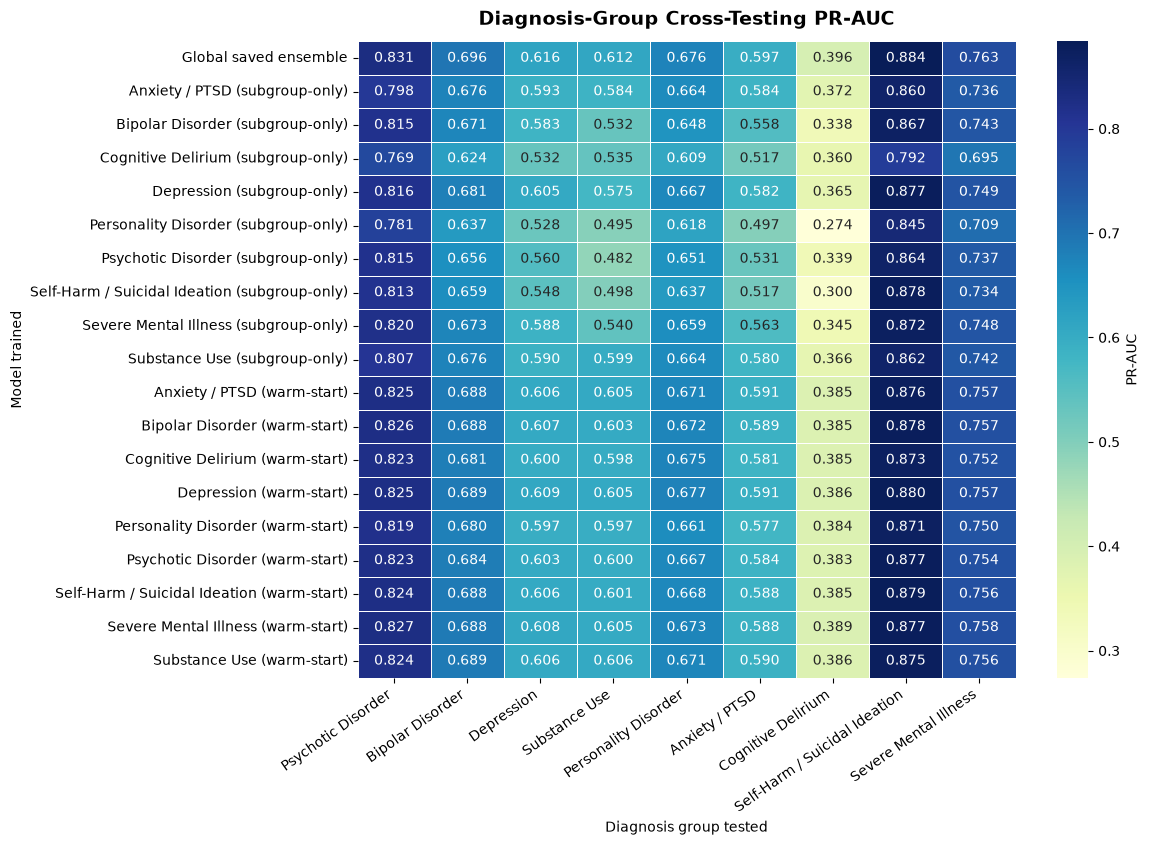

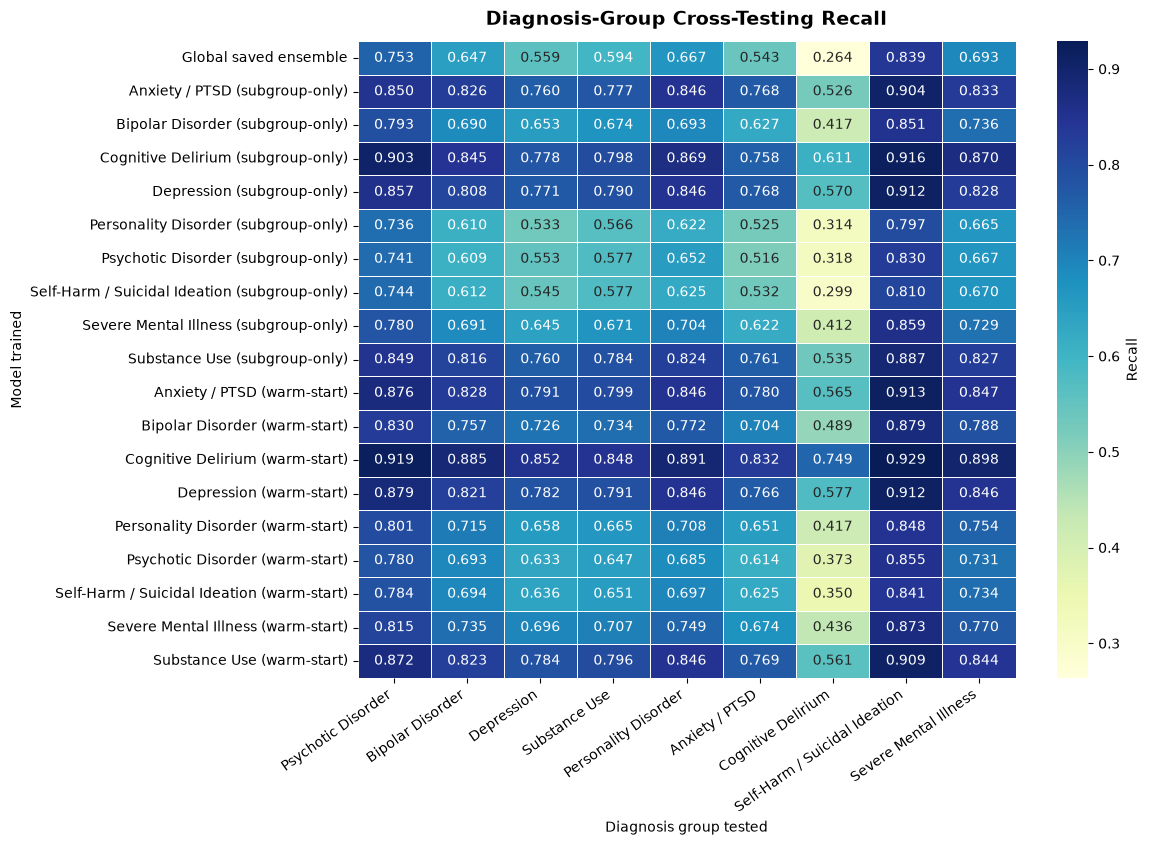

saved diagnosis cross-test table: /Users/ahthini/Desktop/DissProject/outputs/WP3_7/csv_tables/t3_7_diagnosis_cross_test_performance_long.csv
saved PR-AUC heatmap: /Users/ahthini/Desktop/DissProject/outputs/WP3_7/figures/t3_7_diagnosis_cross_test_pr_auc_heatmap.png
saved recall heatmap: /Users/ahthini/Desktop/DissProject/outputs/WP3_7/figures/t3_7_diagnosis_cross_test_recall_heatmap.png


,subgroup_family,subgroup_name,subgroup_value,admissions,readmissions,readmission_rate,mean_predicted_probability,threshold,roc_auc,pr_auc_average_precision,...,model_training_group,model_training_group_label,diagnosis_test_group,diagnosis_test_group_label,training_rows,training_events,local_matrix_test_rows,local_matrix_test_events,heatmap_model_label,model_sort_order
5,diagnosis_cross_testing,has_anxiety_ptsd,global_saved_ensemble,15048,3142,0.2088,0.2704,0.38,0.8012,0.5969,...,global_saved_ensemble,Global Saved Ensemble,has_anxiety_ptsd,Anxiety / PTSD,191320,38039,15048,3142,Global saved ensemble,0
59,diagnosis_cross_testing,has_anxiety_ptsd,has_depression,15048,3142,0.2088,0.3902,0.38,0.7990,0.5914,...,has_depression,Depression,has_anxiety_ptsd,Anxiety / PTSD,77514,16941,15048,3142,Depression (warm-start),2
113,diagnosis_cross_testing,has_anxiety_ptsd,has_anxiety_ptsd,15048,3142,0.2088,0.3972,0.38,0.7988,0.5909,...,has_anxiety_ptsd,Anxiety / PTSD,has_anxiety_ptsd,Anxiety / PTSD,60846,12470,15048,3142,Anxiety / PTSD (warm-start),2
77,diagnosis_cross_testing,has_anxiety_ptsd,has_substance_use,15048,3142,0.2088,0.3867,0.38,0.7986,0.5900,...,has_substance_use,Substance Use,has_anxiety_ptsd,Anxiety / PTSD,80492,17135,15048,3142,Substance Use (warm-start),2
41,diagnosis_cross_testing,has_anxiety_ptsd,has_bipolar_disorder,15048,3142,0.2088,0.3491,0.38,0.7959,0.5888,...,has_bipolar_disorder,Bipolar Disorder,has_anxiety_ptsd,Anxiety / PTSD,15552,4021,15048,3142,Bipolar Disorder (warm-start),2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
120,diagnosis_cross_testing,has_substance_use,has_cognitive_delirium,19942,4148,0.2080,0.4371,0.38,0.7609,0.5347,...,has_cognitive_delirium,Cognitive Delirium,has_substance_use,Substance Use,24963,3551,19942,4148,Cognitive Delirium (subgroup-only),1
30,diagnosis_cross_testing,has_substance_use,has_bipolar_disorder,19942,4148,0.2080,0.3585,0.38,0.7590,0.5325,...,has_bipolar_disorder,Bipolar Disorder,has_substance_use,Substance Use,15552,4021,19942,4148,Bipolar Disorder (subgroup-only),1
138,diagnosis_cross_testing,has_substance_use,has_self_harm_or_suicidal_ideation,19942,4148,0.2080,0.3022,0.38,0.7449,0.4980,...,has_self_harm_or_suicidal_ideation,Self-Harm / Suicidal Ideation,has_substance_use,Substance Use,15279,5522,19942,4148,Self-Harm / Suicidal Ideation (subgroup-only),1
84,diagnosis_cross_testing,has_substance_use,has_personality_disorder,19942,4148,0.2080,0.3014,0.38,0.7354,0.4952,...,has_personality_disorder,Personality Disorder,has_substance_use,Substance Use,4288,1436,19942,4148,Personality Disorder (subgroup-only),1


In [ ]:
#cross-test diagnosis-trained models across all diagnosis-defined test groups
import matplotlib.pyplot as plt
import seaborn as sns

run_diagnosis_cross_testing = True
minimum_cross_training_rows = 3000
minimum_cross_test_rows = 500
minimum_cross_training_events = 100
minimum_cross_test_events = 25

wp3_7_figure_output_path = wp3_7_output_path / "figures"
wp3_7_figure_output_path.mkdir(parents=True, exist_ok=True)

diagnosis_cross_test_long_file = wp3_7_csv_output_path / "t3_7_diagnosis_cross_test_performance_long.csv"
diagnosis_cross_test_pr_auc_file = wp3_7_csv_output_path / "t3_7_diagnosis_cross_test_pr_auc_matrix.csv"
diagnosis_cross_test_recall_file = wp3_7_csv_output_path / "t3_7_diagnosis_cross_test_recall_matrix.csv"
diagnosis_cross_test_pr_auc_figure = wp3_7_figure_output_path / "t3_7_diagnosis_cross_test_pr_auc_heatmap.png"
diagnosis_cross_test_recall_figure = wp3_7_figure_output_path / "t3_7_diagnosis_cross_test_recall_heatmap.png"

#resolve clean-matrix inputs from WP3.1 so this cell can run after a kernel restart
matrix_suffix = "clean_feature_audit"
X_train_path = wp3_1_output_path / f"t3_1_X_train_processed_{matrix_suffix}.npz"
X_test_path = wp3_1_output_path / f"t3_1_X_test_processed_{matrix_suffix}.npz"
y_train_path = wp3_1_output_path / "t3_1_y_train.csv"
y_test_path = wp3_1_output_path / "t3_1_y_test.csv"
train_ids_path = wp3_1_output_path / "t3_1_train_ids.csv"
test_ids_path = wp3_1_output_path / "t3_1_test_ids.csv"
feature_names_path = wp3_1_output_path / f"t3_1_processed_feature_names_{matrix_suffix}.csv"
required_matrix_paths = [X_train_path, X_test_path, y_train_path, y_test_path, train_ids_path, test_ids_path, feature_names_path]


#convert feature-style diagnosis names into readable heatmap labels
def clean_diagnosis_label(column_name):
    label = str(column_name).replace("has_", "").replace("_", " ")
    label = label.replace("self harm or suicidal ideation", "self-harm / suicidal ideation")
    label = label.replace("anxiety ptsd", "anxiety / PTSD")
    return label.title().replace("Ptsd", "PTSD")

#align local model probabilities to the saved prediction cohort before scoring
def make_cross_test_frame(test_mask, probability_values):
    aligned_rows = align_saved_and_local_predictions(test_mask, probability_values)
    if aligned_rows.empty:
        return pd.DataFrame()
    return make_frame_for_probability(aligned_rows["readmitted_30d"], aligned_rows["local_predicted_probability"])

#save a labelled heatmap for report review
def save_diagnosis_cross_heatmap(matrix_df, title, value_label, output_file):
    if matrix_df.empty:
        return
    plt.figure(figsize=(12, max(5, 0.45 * len(matrix_df))))
    ax = sns.heatmap(matrix_df, annot=True, fmt=".3f", cmap="YlGnBu", linewidths=0.5,
        cbar_kws={"label": value_label}, vmin=np.nanmin(matrix_df.to_numpy()), vmax=np.nanmax(matrix_df.to_numpy()))
    ax.set_title(title, fontsize=14, weight="bold", pad=12)
    ax.set_xlabel("Diagnosis group tested")
    ax.set_ylabel("Model trained")
    plt.xticks(rotation=35, ha="right")
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.savefig(output_file, dpi=300, bbox_inches="tight")
    plt.show()

cross_test_rows = []
if run_diagnosis_cross_testing:
    try:
        import lightgbm as lgb
    except Exception:
        lgb = None

    if lgb is None:
        print("LightGBM is unavailable, so diagnosis cross-testing was skipped.")
    elif not all(path.exists() for path in required_matrix_paths):
        print("diagnosis cross-testing inputs are missing")
    else:
        reload_matrix_inputs = ("X_train" not in globals() or "X_test" not in globals() or
            "y_train" not in globals() or "y_test" not in globals() or "train_ids" not in globals() or
            "test_ids" not in globals() or X_train.shape[0] != len(train_ids) or X_test.shape[0] != len(test_ids) or
            len(y_train) != X_train.shape[0] or len(y_test) != X_test.shape[0])
        if reload_matrix_inputs:
            X_train = sparse.load_npz(X_train_path)
            X_test = sparse.load_npz(X_test_path)
            y_train = pd.read_csv(y_train_path)["readmitted_30d"].astype(int)
            y_test = pd.read_csv(y_test_path)["readmitted_30d"].astype(int)
            train_ids = pd.read_csv(train_ids_path)
            test_ids = pd.read_csv(test_ids_path)
        train_subgroup_df = train_ids[id_cols].merge(subgroup_source_df, on=id_cols, how="left")
        test_subgroup_df = test_ids[id_cols].merge(subgroup_source_df, on=id_cols, how="left")
        if "diagnosis_transfer_columns" not in globals():
            diagnosis_transfer_columns = [col for col in ["has_psychotic_disorder", "has_bipolar_disorder", "has_depression",
                "has_substance_use", "has_personality_disorder", "has_anxiety_ptsd", "has_cognitive_delirium",
                "has_self_harm_or_suicidal_ideation", "has_severe_mental_illness"]
                if col in train_subgroup_df.columns and col in test_subgroup_df.columns]

        eligible_diagnosis_columns = []
        diagnosis_masks = {}
        for diagnosis_column in diagnosis_transfer_columns:
            train_mask = pd.to_numeric(train_subgroup_df[diagnosis_column], errors="coerce").fillna(0).gt(0).to_numpy()
            test_mask = pd.to_numeric(test_subgroup_df[diagnosis_column], errors="coerce").fillna(0).gt(0).to_numpy()
            train_events = int(y_train[train_mask].sum()) if train_mask.sum() else 0
            test_events = int(y_test[test_mask].sum()) if test_mask.sum() else 0
            if (train_mask.sum() >= minimum_cross_training_rows and test_mask.sum() >= minimum_cross_test_rows and
                    train_events >= minimum_cross_training_events and test_events >= minimum_cross_test_events and
                    y_train[train_mask].nunique() == 2 and y_test[test_mask].nunique() == 2):
                eligible_diagnosis_columns.append(diagnosis_column)
                diagnosis_masks[diagnosis_column] = {"train_mask": train_mask, "test_mask": test_mask,
                    "training_rows": int(train_mask.sum()), "training_events": train_events,
                    "local_matrix_test_rows": int(test_mask.sum()), "local_matrix_test_events": test_events}

        if not eligible_diagnosis_columns:
            print("no diagnosis groups met the cross-testing sample criteria")
        else:
            if "global_base_model" not in globals():
                global_base_model = lgb.LGBMClassifier(n_estimators=250, learning_rate=0.035, num_leaves=63, max_depth=-1,
                    min_child_samples=75, subsample=0.9, colsample_bytree=0.7, reg_alpha=0.5, reg_lambda=20,
                    class_weight="balanced", random_state=42, n_jobs=-1, verbose=-1)
                print("training global LightGBM base model for diagnosis cross-testing...")
                global_base_model.fit(X_train, y_train)

            trained_models = [{"model_training_group": "global_saved_ensemble", "model_variant": "saved_global_model", "model": None,
                "training_rows": len(y_train), "training_events": int(y_train.sum())}]
            for diagnosis_column in eligible_diagnosis_columns:
                train_mask = diagnosis_masks[diagnosis_column]["train_mask"]
                print("training cross-test diagnosis model:", diagnosis_column)
                subgroup_only_model = lgb.LGBMClassifier(n_estimators=250, learning_rate=0.035, num_leaves=63, max_depth=-1,
                    min_child_samples=50, subsample=0.9, colsample_bytree=0.75, reg_alpha=0.5, reg_lambda=20,
                    class_weight="balanced", random_state=42, n_jobs=-1, verbose=-1)
                subgroup_only_model.fit(X_train[train_mask], y_train[train_mask])
                trained_models.append({"model_training_group": diagnosis_column, "model_variant": "subgroup_only_lightgbm",
                    "model": subgroup_only_model, "training_rows": diagnosis_masks[diagnosis_column]["training_rows"],
                    "training_events": diagnosis_masks[diagnosis_column]["training_events"]})

                fine_tuned_model = lgb.LGBMClassifier(n_estimators=120, learning_rate=0.025, num_leaves=63, max_depth=-1,
                    min_child_samples=50, subsample=0.9, colsample_bytree=0.75, reg_alpha=0.75, reg_lambda=25,
                    class_weight="balanced", random_state=43, n_jobs=-1, verbose=-1)
                fine_tuned_model.fit(X_train[train_mask], y_train[train_mask], init_model=global_base_model.booster_)
                trained_models.append({"model_training_group": diagnosis_column, "model_variant": "global_warm_start_fine_tuned_lightgbm",
                    "model": fine_tuned_model, "training_rows": diagnosis_masks[diagnosis_column]["training_rows"],
                    "training_events": diagnosis_masks[diagnosis_column]["training_events"]})

            for model_info in trained_models:
                for diagnosis_column in eligible_diagnosis_columns:
                    test_mask = diagnosis_masks[diagnosis_column]["test_mask"]
                    if model_info["model_variant"] == "saved_global_model":
                        aligned_rows = align_saved_and_local_predictions(test_mask)
                        score_frame = aligned_rows[["readmitted_30d", "predicted_probability"]].copy() if not aligned_rows.empty else pd.DataFrame()
                    else:
                        probability = model_info["model"].predict_proba(X_test[test_mask])[:, 1]
                        score_frame = make_cross_test_frame(test_mask, probability)
                    if score_frame.empty or score_frame["readmitted_30d"].nunique() < 2:
                        continue
                    metrics = evaluate_subgroup(score_frame, "diagnosis_cross_testing", diagnosis_column, model_info["model_training_group"])
                    cross_test_rows.append({**metrics,
                        "model_variant": model_info["model_variant"],
                        "model_training_group": model_info["model_training_group"],
                        "model_training_group_label": clean_diagnosis_label(model_info["model_training_group"]),
                        "diagnosis_test_group": diagnosis_column,
                        "diagnosis_test_group_label": clean_diagnosis_label(diagnosis_column),
                        "training_rows": int(model_info["training_rows"]),
                        "training_events": int(model_info["training_events"]),
                        "local_matrix_test_rows": diagnosis_masks[diagnosis_column]["local_matrix_test_rows"],
                        "local_matrix_test_events": diagnosis_masks[diagnosis_column]["local_matrix_test_events"]})

diagnosis_cross_test_long_df = pd.DataFrame(cross_test_rows)
if diagnosis_cross_test_long_df.empty:
    diagnosis_cross_test_long_df.to_csv(diagnosis_cross_test_long_file, index=False)
    diagnosis_cross_test_pr_auc_matrix_df = pd.DataFrame()
    diagnosis_cross_test_recall_matrix_df = pd.DataFrame()
    diagnosis_cross_test_pr_auc_matrix_df.to_csv(diagnosis_cross_test_pr_auc_file, index=False)
    diagnosis_cross_test_recall_matrix_df.to_csv(diagnosis_cross_test_recall_file, index=False)
    display(pd.DataFrame({"message": ["diagnosis cross-testing did not produce eligible rows"]}))
else:
    diagnosis_cross_test_long_df.to_csv(diagnosis_cross_test_long_file, index=False)
    diagnosis_cross_test_long_df["heatmap_model_label"] = np.where(
        diagnosis_cross_test_long_df["model_variant"].eq("saved_global_model"),
        "Global saved ensemble",
        diagnosis_cross_test_long_df["model_training_group_label"] + " (" +
        diagnosis_cross_test_long_df["model_variant"].replace({
            "subgroup_only_lightgbm": "subgroup-only",
            "global_warm_start_fine_tuned_lightgbm": "warm-start"}) + ")")
    variant_order = {"saved_global_model": 0, "subgroup_only_lightgbm": 1, "global_warm_start_fine_tuned_lightgbm": 2}
    diagnosis_cross_test_long_df["model_sort_order"] = diagnosis_cross_test_long_df["model_variant"].map(variant_order).fillna(9)
    model_order = (diagnosis_cross_test_long_df[["heatmap_model_label", "model_sort_order", "model_training_group_label"]]
        .drop_duplicates().sort_values(["model_sort_order", "model_training_group_label"])["heatmap_model_label"].tolist())
    test_order = [clean_diagnosis_label(col) for col in eligible_diagnosis_columns]

    diagnosis_cross_test_pr_auc_matrix_df = diagnosis_cross_test_long_df.pivot_table(index="heatmap_model_label",
        columns="diagnosis_test_group_label", values="pr_auc_average_precision", aggfunc="first").reindex(index=model_order, columns=test_order)
    diagnosis_cross_test_recall_matrix_df = diagnosis_cross_test_long_df.pivot_table(index="heatmap_model_label",
        columns="diagnosis_test_group_label", values="recall_sensitivity", aggfunc="first").reindex(index=model_order, columns=test_order)

    diagnosis_cross_test_pr_auc_matrix_df.to_csv(diagnosis_cross_test_pr_auc_file)
    diagnosis_cross_test_recall_matrix_df.to_csv(diagnosis_cross_test_recall_file)

    save_diagnosis_cross_heatmap(diagnosis_cross_test_pr_auc_matrix_df,
        "Diagnosis-Group Cross-Testing PR-AUC", "PR-AUC", diagnosis_cross_test_pr_auc_figure)
    save_diagnosis_cross_heatmap(diagnosis_cross_test_recall_matrix_df,
        "Diagnosis-Group Cross-Testing Recall", "Recall", diagnosis_cross_test_recall_figure)

    print("saved diagnosis cross-test table:", diagnosis_cross_test_long_file)
    print("saved PR-AUC heatmap:", diagnosis_cross_test_pr_auc_figure)
    print("saved recall heatmap:", diagnosis_cross_test_recall_figure)
    display(diagnosis_cross_test_long_df.sort_values(["diagnosis_test_group", "pr_auc_average_precision"], ascending=[True, False]).round(4))

##### **Export Workbook**

This section saves every subgroup table as a CSV and compiles the key tables into one workbook for easier review.

In [255]:
#compile subgroup outputs into one workbook while preserving the csv files
workbook_path = wp3_7_output_path / "t3_7_subgroup_analysis_tables.xlsx"
workbook_tables = {
    "join_audit": subgroup_join_audit_df,
    "global_subgroup_performance": subgroup_performance_df,
    "subgroup_contrasts": subgroup_contrast_df,
    "error_enrichment": error_enrichment_df,
    "intersection_subgroups": intersection_subgroup_df,
    "reliability_summary": subgroup_reliability_summary_df if "subgroup_reliability_summary_df" in globals() else pd.DataFrame(),
    "metric_bootstrap_ci": subgroup_metric_ci_df if "subgroup_metric_ci_df" in globals() else pd.DataFrame(),
    "demographic_fairness": demographic_fairness_df if "demographic_fairness_df" in globals() else pd.DataFrame(),
    "error_profile_summary": error_profile_summary_df if "error_profile_summary_df" in globals() else pd.DataFrame(),
    "outcome_window_rates": subgroup_outcome_window_summary_df if "subgroup_outcome_window_summary_df" in globals() else pd.DataFrame(),
    "fp_follow_forward": false_positive_follow_forward_df if "false_positive_follow_forward_df" in globals() else pd.DataFrame(),
    "subgroup_calibration": subgroup_calibration_summary_df if "subgroup_calibration_summary_df" in globals() else pd.DataFrame(),
    "report_rankings": subgroup_report_ranking_df if "subgroup_report_ranking_df" in globals() else pd.DataFrame(),
    "older_patient_focus": older_patient_focus_df if "older_patient_focus_df" in globals() else pd.DataFrame(),
    "narrative_summary": report_narrative_summary_df if "report_narrative_summary_df" in globals() else pd.DataFrame(),
    "key_finding_summary": key_subgroup_finding_summary_df if "key_subgroup_finding_summary_df" in globals() else pd.DataFrame(),
    "age_subgroup_training": age_subgroup_training_df if "age_subgroup_training_df" in globals() else pd.DataFrame(),
    "diagnosis_transfer_learning": diagnosis_transfer_learning_df if "diagnosis_transfer_learning_df" in globals() else pd.DataFrame(),
    "diagnosis_cross_test_long": diagnosis_cross_test_long_df if "diagnosis_cross_test_long_df" in globals() else pd.DataFrame(),
    "diagnosis_cross_pr_auc": diagnosis_cross_test_pr_auc_matrix_df.reset_index() if "diagnosis_cross_test_pr_auc_matrix_df" in globals() else pd.DataFrame(),
    "diagnosis_cross_recall": diagnosis_cross_test_recall_matrix_df.reset_index() if "diagnosis_cross_test_recall_matrix_df" in globals() else pd.DataFrame()}
with pd.ExcelWriter(workbook_path) as writer:
    for sheet_name, table_df in workbook_tables.items():
        table_df.to_excel(writer, sheet_name=sheet_name[:31], index=False)

summary_df = pd.DataFrame([{
    "prediction_source_path": str(prediction_source["path"]),
    "prediction_source_label": prediction_source["source_label"],
    "primary_threshold": primary_threshold,
    "test_admissions": len(analysis_df),
    "overall_readmission_rate": analysis_df["readmitted_30d"].mean(),
    "subgroup_definitions": len(subgroup_definitions),
    "workbook_path": str(workbook_path)}])
summary_df.to_csv(wp3_7_csv_output_path / "t3_7_subgroup_analysis_summary.csv", index=False)
print("saved workbook:", workbook_path)
print("saved csv folder:", wp3_7_csv_output_path)
display(summary_df)

saved workbook: /Users/ahthini/Desktop/DissProject/outputs/WP3_7/t3_7_subgroup_analysis_tables.xlsx
saved csv folder: /Users/ahthini/Desktop/DissProject/outputs/WP3_7/csv_tables


,prediction_source_path,prediction_source_label,primary_threshold,test_admissions,overall_readmission_rate,subgroup_definitions,workbook_path
0,/Users/ahthini/Desktop/DissProject/outputs/WP3...,ensemble,0.38,47171,0.197558,88,/Users/ahthini/Desktop/DissProject/outputs/WP3...
